In [1]:
import xarray as xr
import seaborn as sns
import seaborn.objects as so 
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import flox.xarray
from tqdm.notebook import tqdm
import cartopy.crs as ccrs
import pandas as pd
plt.style.use('robin')
mpl.rcParams['axes.grid'] = True

In [2]:
%matplotlib inline

In [3]:
# from dask.distributed import Client, LocalCluster

# cluster = LocalCluster(
#     n_workers=4,
#     threads_per_worker=1,
#     memory_limit='16GB',
#     scheduler_port=0,  # use random available port
# )

# client = Client(cluster)

In [4]:
"""
dd3j4xy3 is only u wind
hsrny3md is all variables

"""
run_id = 'hsrny3md'  # 

In [ ]:
ds = xr.open_dataset(f'/Data/gfi/users/rogui7909/data/NN_outputs/attributions/{run_id}_attributions_all.nc')
ds['hard_targets'] = ds.targets.where(ds.targets==1,0)
max_dist = ds.distance_to_cyclone.min(['longitude','latitude'])
cyclones_tracking_times = max_dist.notnull().sum('timestep_past')
ds['cyclones_tracking_times'] = cyclones_tracking_times.fillna(0)
# days_with_cyclone = ds.distance_to_cyclone.isel(longitude=50, latitude=40).notnull().sum()


# Evaluate model performance

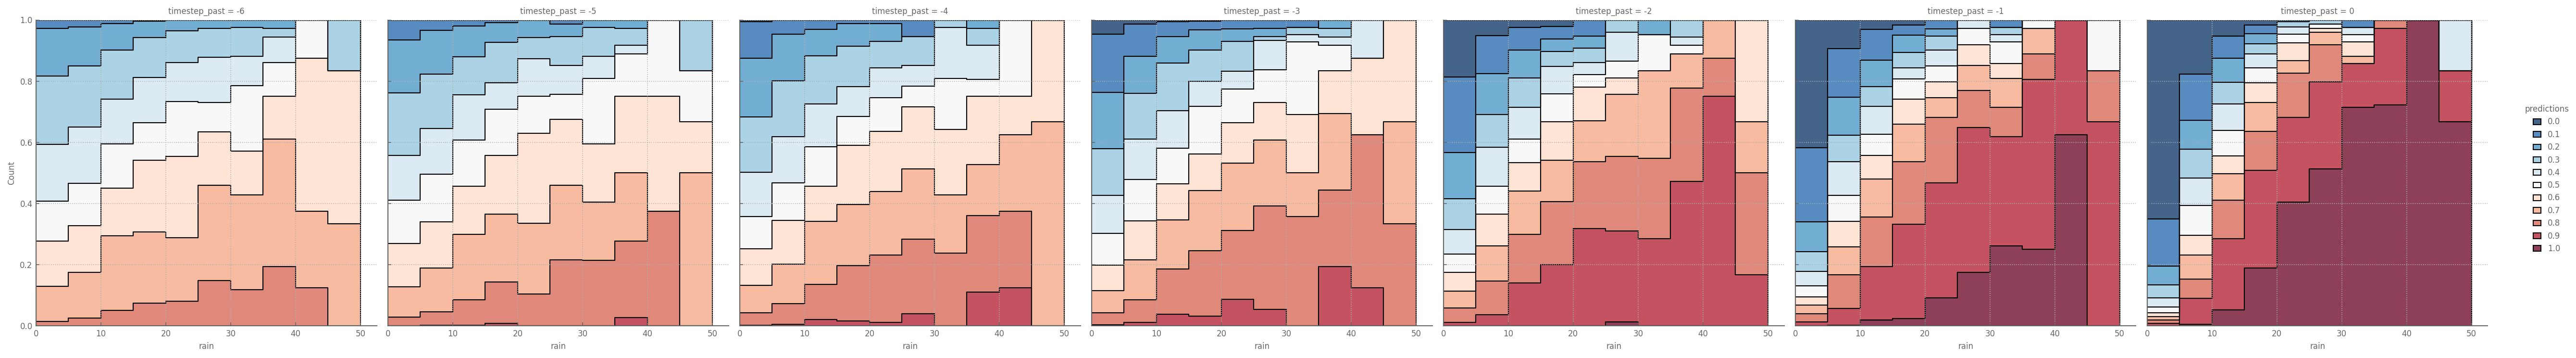

In [ ]:
df_ = ds[['predictions','rain']].to_dataframe()
df_['predictions']=df_.predictions.round(1)

sns.displot(df_, x='rain', hue='predictions', multiple='fill', bins=np.arange(0,80,5), kind='hist', palette='RdBu_r', col='timestep_past',element='step' )

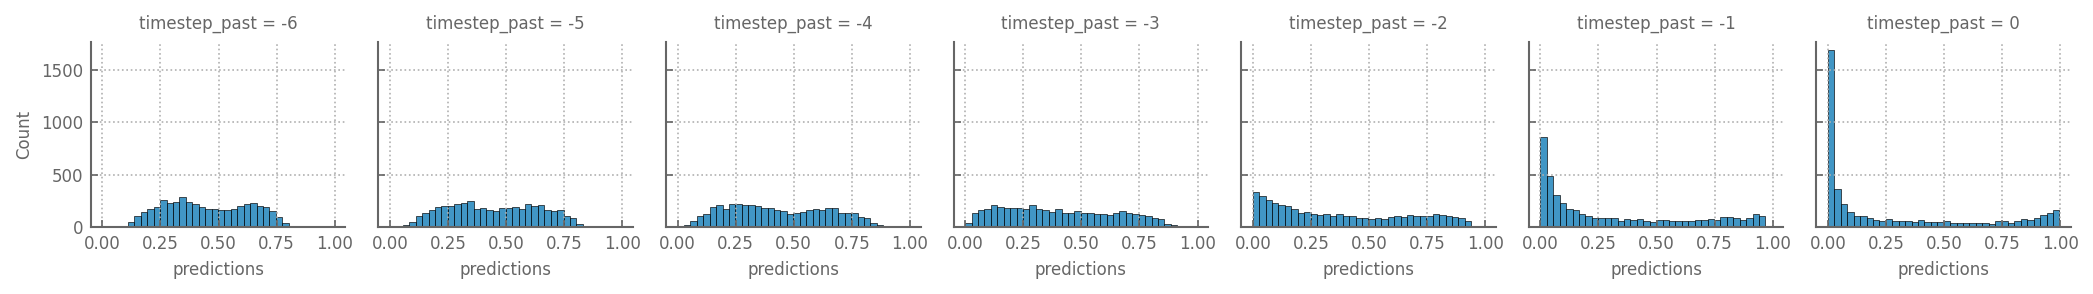

In [ ]:
sns.displot(ds.predictions.to_series().reset_index(),x='predictions', kind='hist', col='timestep_past', height=2)

In [ ]:
thresh = xr.DataArray(np.arange(0.,1.0001,.01), dims=['proba_thresh'], coords=dict(proba_thresh = np.arange(0.,1.0001,.01)))
TP = ((ds.predictions>thresh) & (ds.hard_targets>thresh)).sum(['time_of_event'])
precision = TP/((ds.predictions>thresh)).sum(['time_of_event'])
recall = TP/(ds.hard_targets>thresh).sum(['time_of_event'])
f1 = 2*recall*precision/(recall+precision)

f1_best = f1.max('proba_thresh')
f1_thresh = f1.idxmax('proba_thresh')

TP_all = ((ds.predictions>thresh) & (ds.hard_targets>thresh)).sum(['time_of_event','timestep_past'])
precision_all = TP_all/((ds.predictions>thresh)).sum(['time_of_event','timestep_past'])
recall_all = TP_all/(ds.hard_targets>thresh).sum(['time_of_event','timestep_past'])
f1_all = 2*recall_all*precision_all/(recall_all+precision_all)

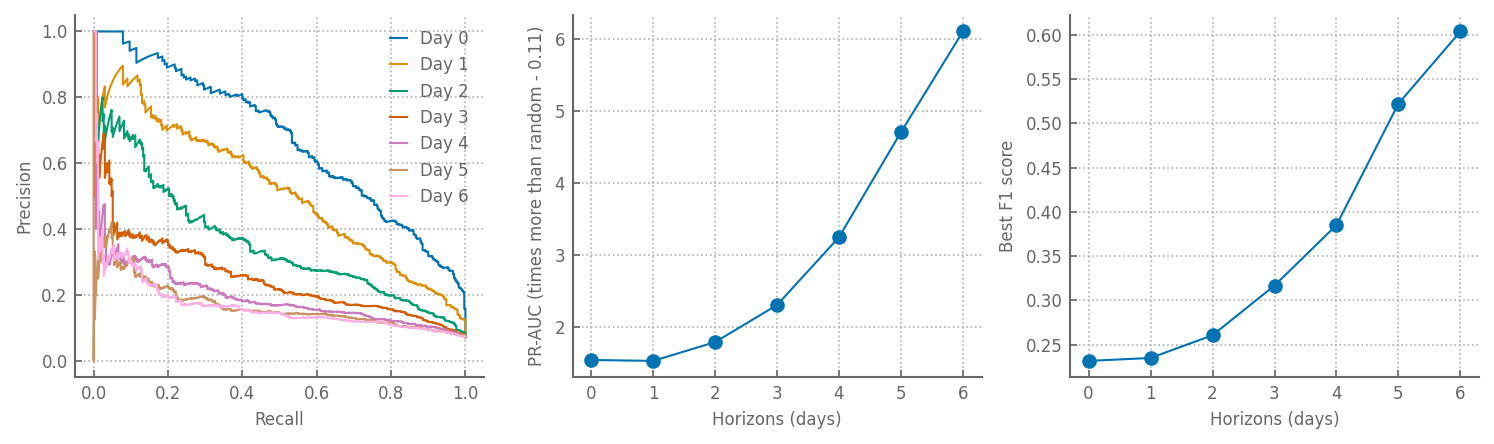

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score
fig, axs = plt.subplots(1,3,figsize=(10,3))
aps=[]
for k in range(7):
    targets = 1*(ds.targets==1).values[:,6-k]
    predictions = ds.predictions.values[:,6-k]
    aps.append(average_precision_score(targets, predictions, pos_label=1)/.11)
    prec, recall, thresholds = precision_recall_curve(targets, predictions, pos_label=1)
    axs[0].plot(recall, prec, label=f'Day {k}')
axs[0].set_xlabel('Recall')
axs[0].set_ylabel('Precision')
axs[0].legend()

axs[1].plot(np.arange(6,-1,-1),aps, marker='o')
axs[1].set_ylabel('PR-AUC (times more than random - 0.11)')
axs[1].set_xlabel('Horizons (days)')

axs[2].plot(np.arange(0,7,1), f1_best.values, marker='o')
axs[2].set_xlabel('Horizons (days)')
axs[2].set_ylabel('Best F1 score')

plt.tight_layout()

# ATTRIBUTIONS

In [ ]:
TP = (ds.predictions > f1_thresh) & (ds.hard_targets == 1)
extr = (ds.hard_targets == 1)
time_TP = (ds.time_of_event).where(TP.sum('timestep_past')>0 , drop=True)
time_extr = (ds.time_of_event).where(extr.sum('timestep_past')>0, drop=True)

ds_TP = ds.sel(time_of_event=time_TP).where(TP.sel(time_of_event=time_TP))
ds_extr = ds.sel(time_of_event=time_extr).where(extr.sel(time_of_event=time_extr))


NameError: name 'ds' is not defined

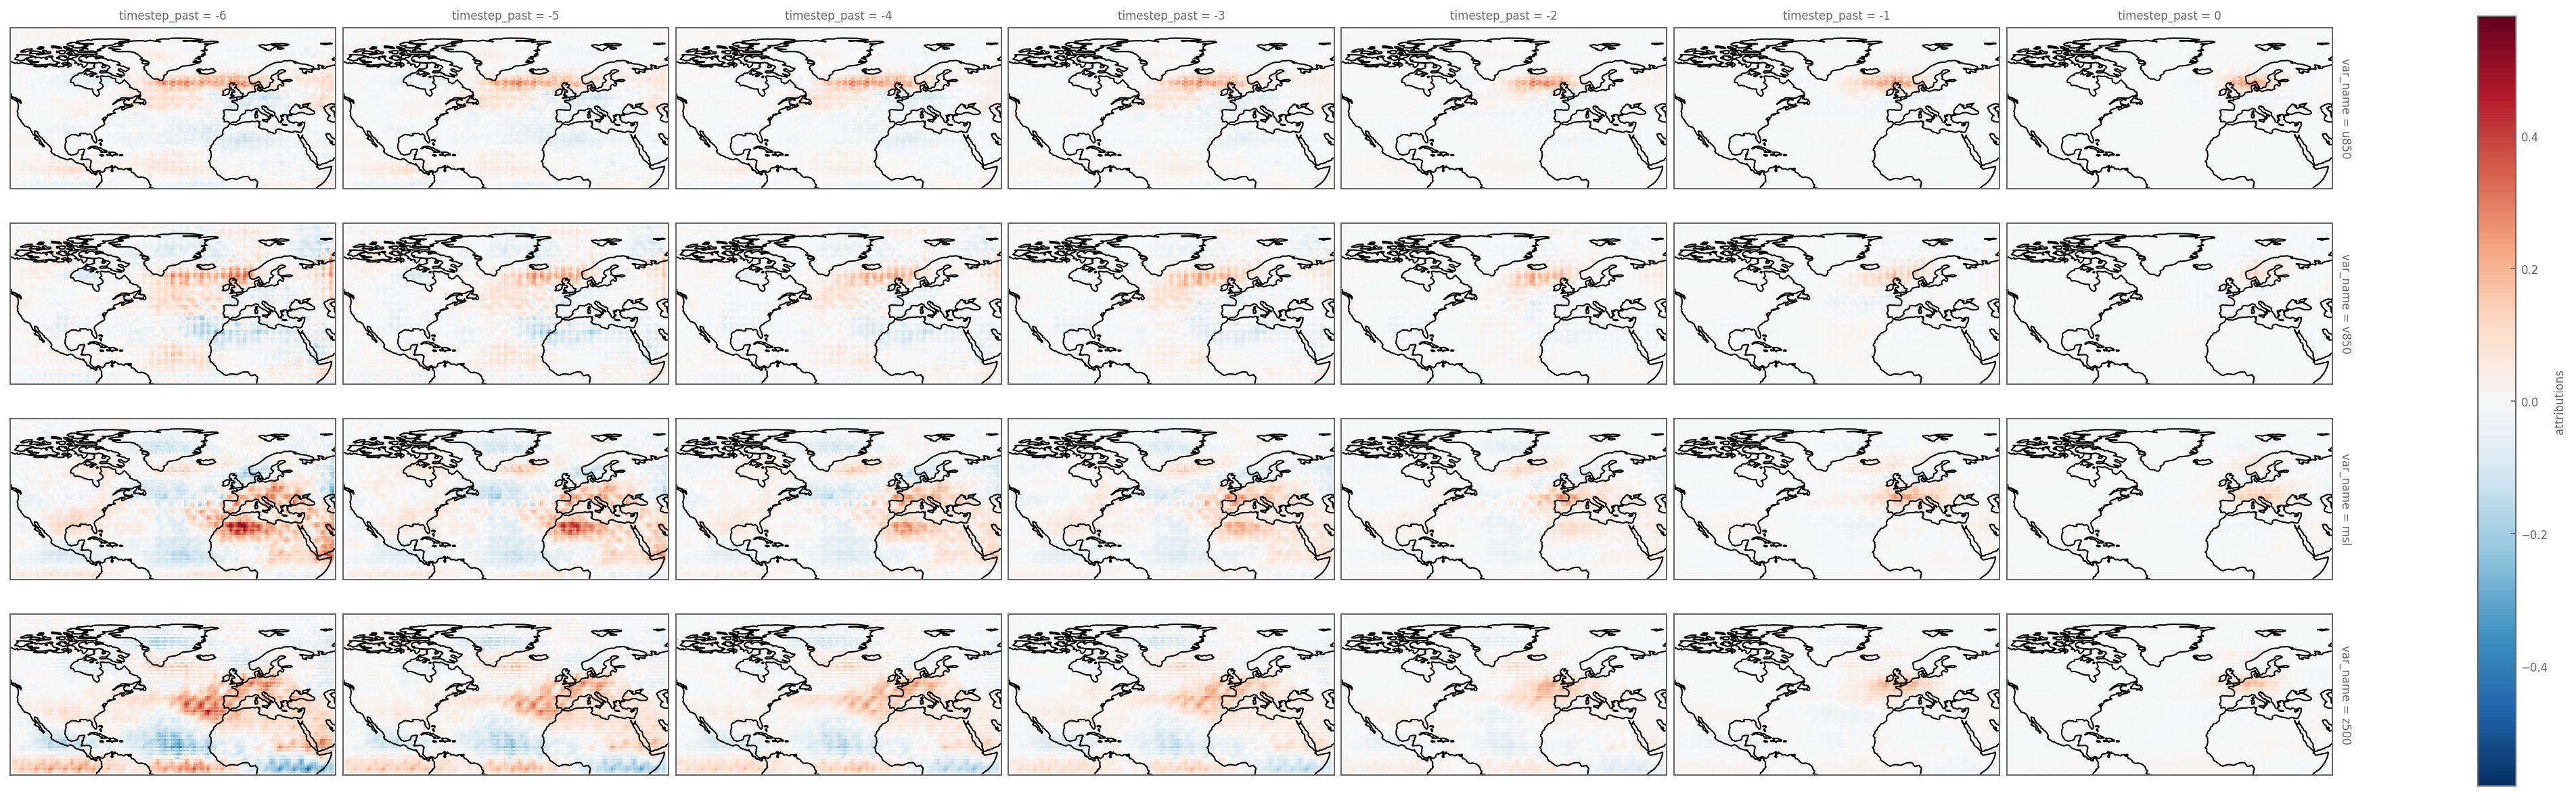

In [ ]:
attrs_TP = ds_TP.attributions.mean('time_of_event')
ds_ = attrs_TP/attrs_TP.max(['longitude','latitude', 'var_name'])
plot = ds_.rolling(longitude=3, latitude=3, center=True).mean().plot(col='timestep_past', row='var_name',
             subplot_kws = dict(projection=ccrs.PlateCarree()),
              transform=ccrs.PlateCarree(),
             aspect=2, size=2)
for ax in plot.axs.flatten():
    ax.coastlines()


# Cyclones stuff

In [32]:
cycs = xr.open_dataset('/Data/gfi/spengler/kko033/cyclone_clustering/data/all_combined_NH_trcks.nc').to_dataframe().set_index('track_id').sort_index()
df_features = pd.read_csv("/Data/gfi/users/rogui7909/data/attribute_precip_features/western_norway/features_attributed_to_rain_per_day_WN.csv",index_col=0, parse_dates=True).loc[ds.time_of_event]
def get_cyclones_per_day(line):
    line_extract = line[:-2].dropna()
    series = pd.Series(line_extract.loc[[k.startswith('C_') for k in line_extract]].values).dropna()
    return pd.Series([int(k.split('_')[1]) for k in series])
    # return pd.Series(line_extract.loc[[k.startswith('C_') for k in line_extract]].values).dropna()
cyclones_per_day = df_features.apply(get_cyclones_per_day, axis=1)

all_cyclones = cyclones_per_day.stack().unique()
cycs_lc = cycs.loc[all_cyclones]

def get_ds_cyc_lc(date):
    line = cyclones_per_day.loc[date].dropna()
    # if line.size!=0:
    full_cyc_lc = cycs_lc.loc[line]
    full_cyc_lc['date'] = pd.to_datetime(full_cyc_lc.date)
    lc_before_date = full_cyc_lc.loc[full_cyc_lc.date.dt.date<=line.name.date()]
    lc_before_date['timestep_past'] = lc_before_date.date - line.name
    # return lc_before_date.reset_index().set_index(['track_id','timestep_past']).to_xarray().assign_coords(time_of_event=date)
    individual_tracks = list(lc_before_date.index.unique())
    lc_before_date['track_number']=[individual_tracks.index(k) for k in lc_before_date.index]
    ds_tracks = lc_before_date.reset_index().set_index(['track_number','timestep_past']).to_xarray().assign_coords(time_of_event=date)
    ds_tracks['track_id'] = ds_tracks.track_id.isel(timestep_past=0)
    return ds_tracks
ds_cycs = xr.concat([get_ds_cyc_lc(time) for time in tqdm(cyclones_per_day.dropna(how='all').index)], dim='time_of_event')
ds_cycs = xr.merge([ds_cycs, ds.rain])

  0%|          | 0/2823 [00:00<?, ?it/s]

/tmp/ipykernel_27996/3956440339.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  lc_before_date['timestep_past'] = lc_before_date.date - line.name
/tmp/ipykernel_27996/3956440339.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  lc_before_date['track_number']=[individual_tracks.index(k) for k in lc_before_date.index]
/tmp/ipykernel_27996/3956440339.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

/tmp/ipykernel_27996/3572282162.py:8: UserWarning: The palette list has more values (22) than needed (19), which may not be intended.
  sns.displot(df_, x='rain', hue='cyclones_tracking_times', bins=[0,12,20,100], multiple='fill', palette=cmap)


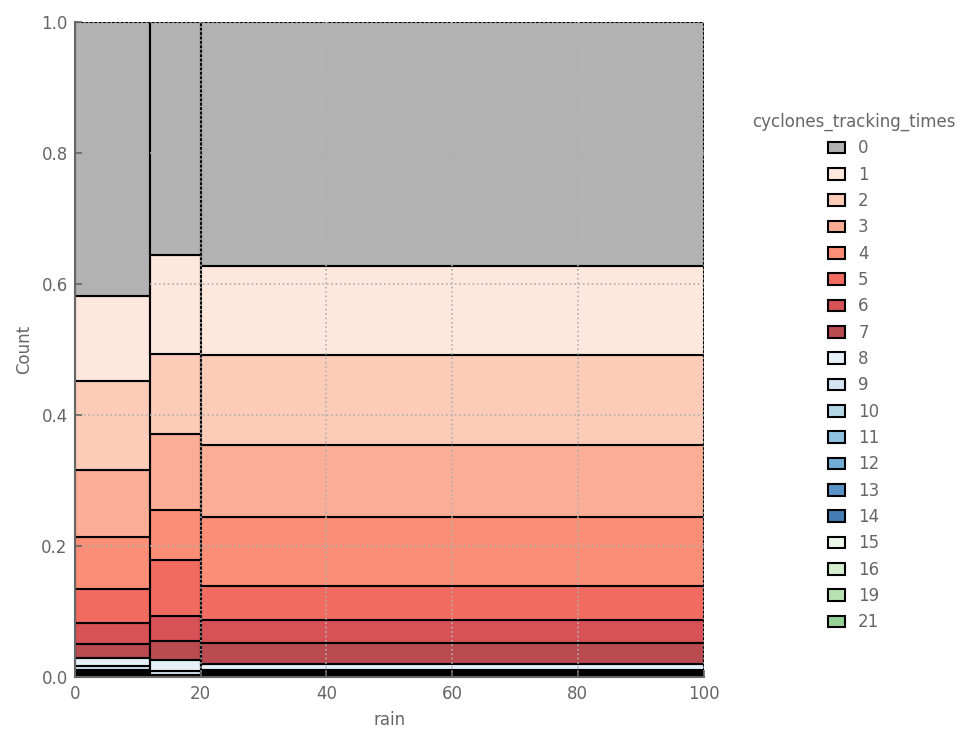

In [ ]:
ds_cycs = xr.merge([ds_cycs, ds.rain.isel(timestep_past=0)])
ds_cycs['cyclones_tracking_times'] = ds_cycs.lon.max('track_number').count('timestep_past')
df_ = ds_cycs.sel(timestep_past=0)[['rain','cyclones_tracking_times']].to_dataframe()

df_['cyclones_tracking_times'] = df_.cyclones_tracking_times//8

cmap = [(.6,.6,.6)] + sns.color_palette('Reds', 7) + sns.color_palette('Blues', 7) +sns.color_palette('Greens', 7)

sns.displot(df_, x='rain', hue='cyclones_tracking_times', bins=[0,12,20,100], multiple='fill', palette=cmap)
    


In [55]:
ds_TP.sel(timestep_past=-6).predictions.to_series().sort_values().dropna()


time_of_event
2004-12-26    0.661185
1999-10-25    0.661464
2006-11-12    0.661774
2011-12-17    0.661911
2007-03-09    0.662484
                ...   
2008-01-23    0.800614
2008-10-12    0.819025
2005-01-06    0.819908
2005-01-10    0.825745
2005-01-04    0.831772
Name: predictions, Length: 124, dtype: float32

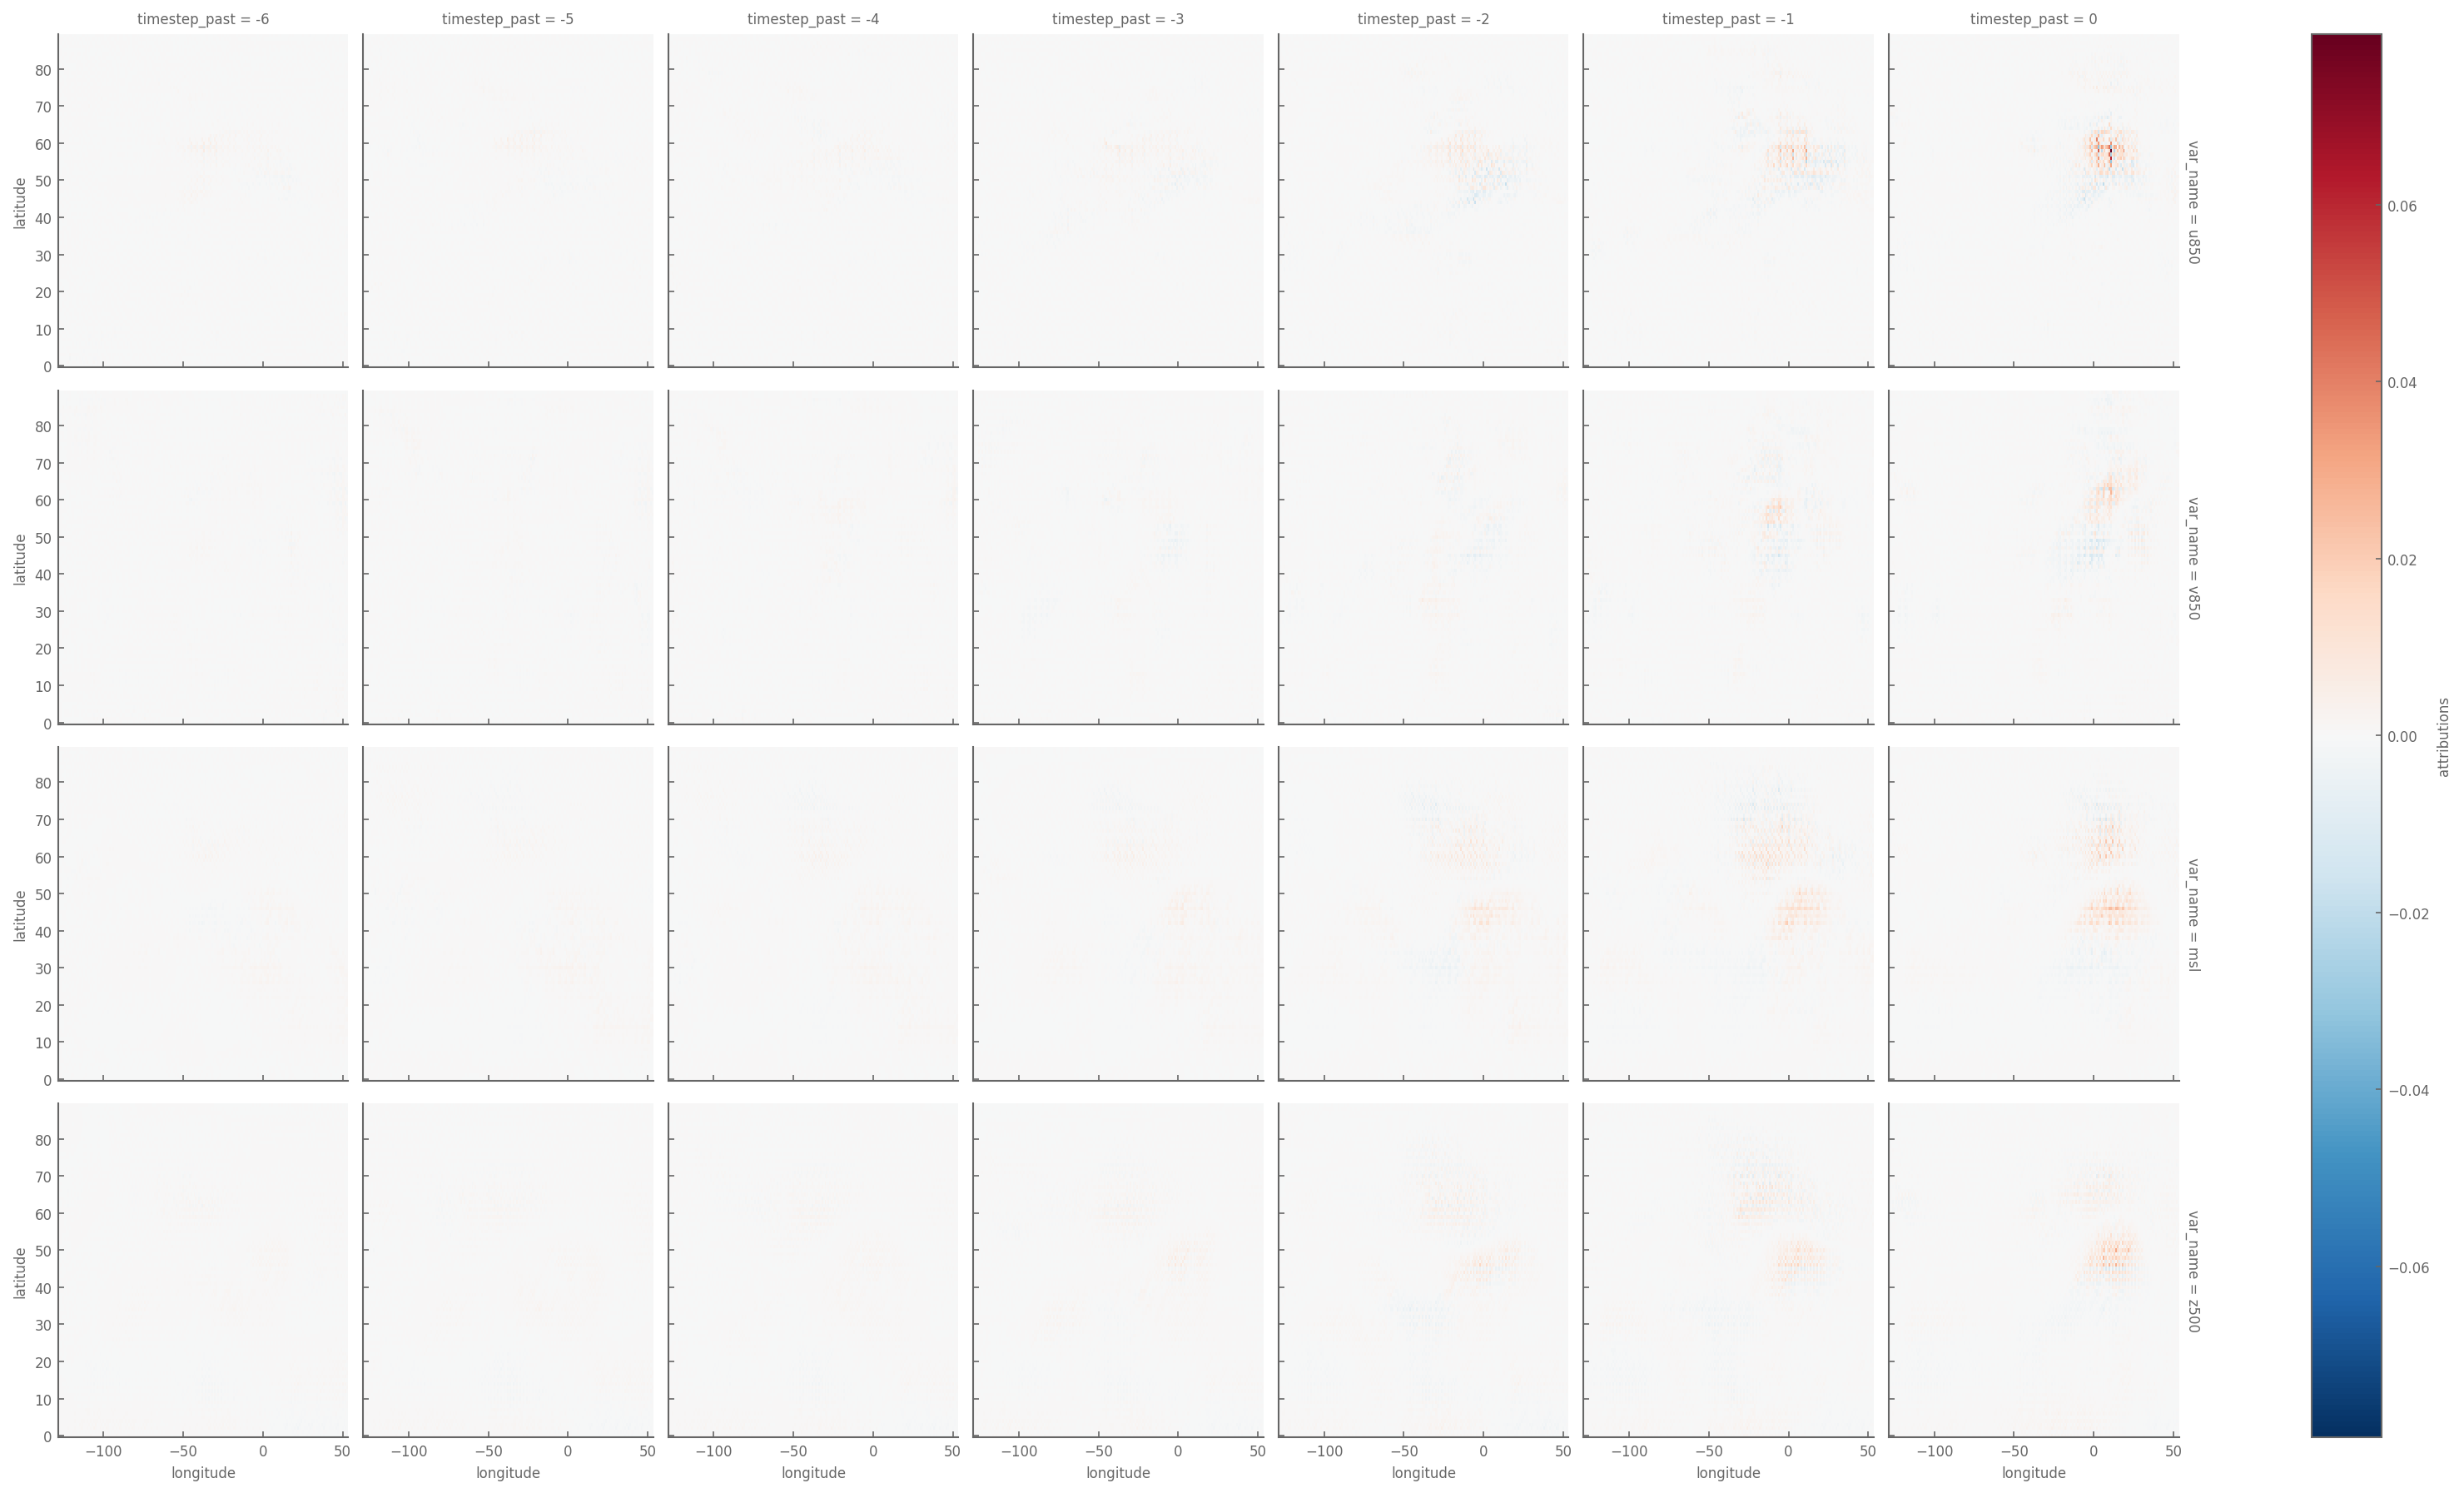

In [ ]:
ds_day = ds_TP.sel(time_of_event='2005-01-04').attributions

(ds_day/ds_day.max(['longitude','latitude'])).plot(col='timestep_past', row='var_name')


In [41]:

attributions_per_distance = flox.xarray.xarray_reduce(
    # variable qu'on veut aggréger 
    ds_TP.attributions,
    # Variables selon lesquelles on veut grouer : ici il y a deux variables mais on peut en rajouter autant qu'on veut
    ds_TP.distance_to_cyclone,
    ds_TP.timestep_past,
    ds_TP.time_of_event,
    ds_TP.var_name,
    # Fonction à appliquer à chacun des groupes pour aggrégation
    func="mean",
    # Groupes attendus pour chacune des variables : soit on met les bins, soit on met None quand on veut grouper pour toutes les valeurs possibles
    expected_groups=(ds_TP.distance_to_cyclone.quantile(np.arange(0,1.0001,.02)),
                    # np.arange(0,10001,500),
                    # np.arange(0,1.,.02), 
                     None,
                     None,
                     None,),
    # Déterminer si les groupes donnés correspondent à des bins ou non
    isbin=[True, False,False,False],
    # Méthode de calcul parallèl : flox propose plein de méthodes différentes pour optimiser les calculs en fonction de la forme des données
    method="map-reduce",
)
attributions_per_distance['distance_to_cyclone_bins'] = [k.left for k in attributions_per_distance.distance_to_cyclone_bins.values]
attributions_per_distance = attributions_per_distance.rename(distance_to_cyclone_bins='Distance_to_cyclone')

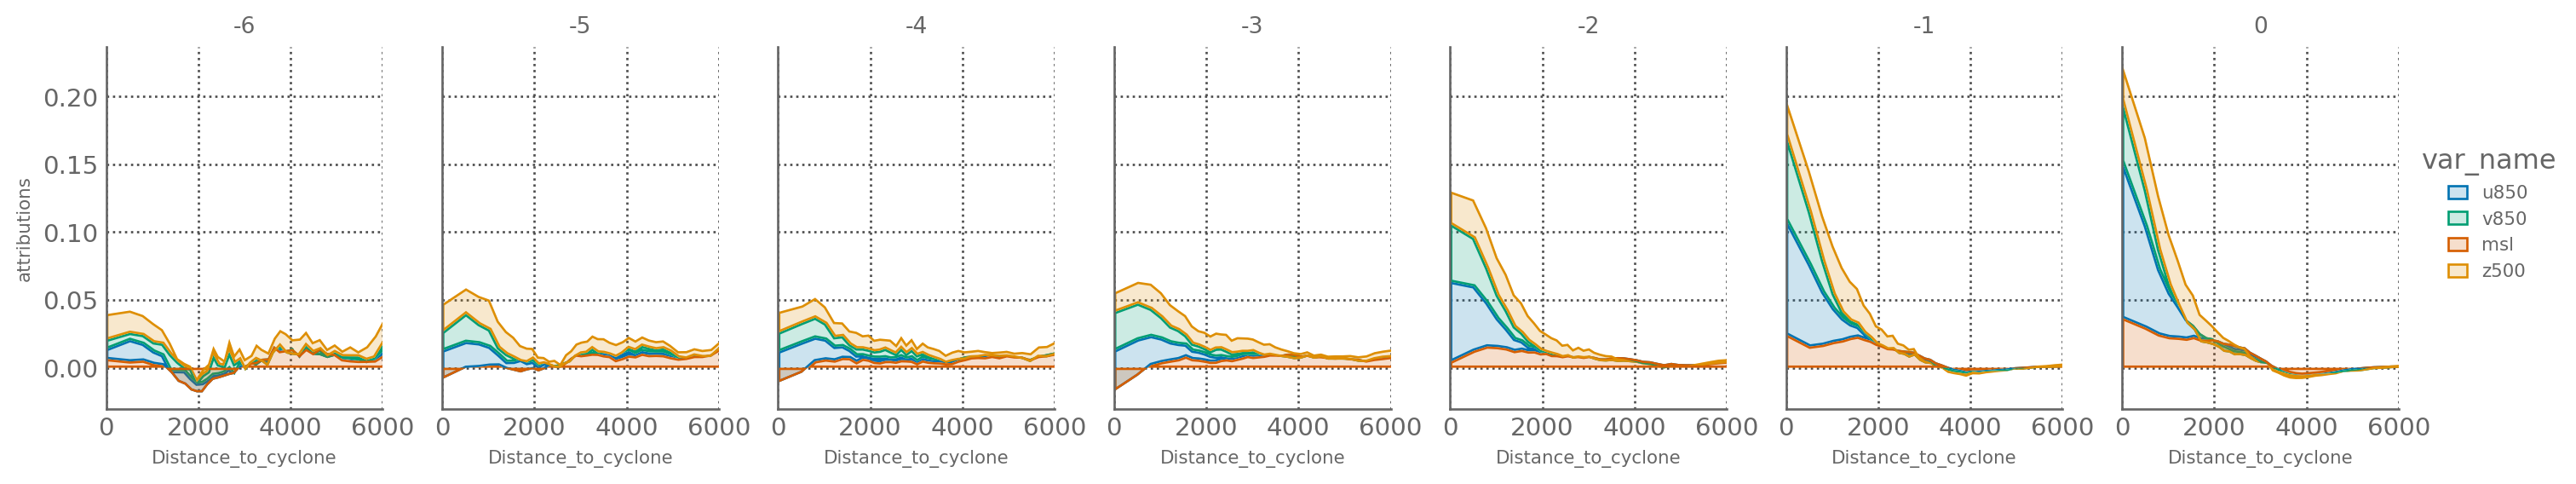

In [43]:
mean_cumulative_attr = attributions_per_distance.sum(['Distance_to_cyclone','var_name'], min_count=1).mean('time_of_event')
df__ = ((attributions_per_distance).where(TP).mean('time_of_event')/mean_cumulative_attr).to_series().reset_index()
df__['var_type'] = ['wind' if '850' in k else 'pressure' for k in df__.var_name]

# sns.catplot(df__, x='dist_to_cyclone_bins', y='attributions', kind='bar', hue='var_name', multiple)#
(so.Plot(df__,x='Distance_to_cyclone', y='attributions', color='var_name' )
    .add(so.Area(), so.Stack())
    .facet(col='timestep_past', )
    .layout(size=(15,3))
    .theme(plt.style.library["robin"])
    .theme({'axes.grid':True, 'grid.color':'.3'})
    # .share(y=False)
    .limit(x=[0,6000])
    .scale(color=so.Nominal(['C0','C2','C3','C1'],order=['u850','v850','msl','z500',]))
    # .scale(x='log')
    )

# axs = f.axes

# , hue='var_name', multiple='stack')
# df__

## Distance to Bergen

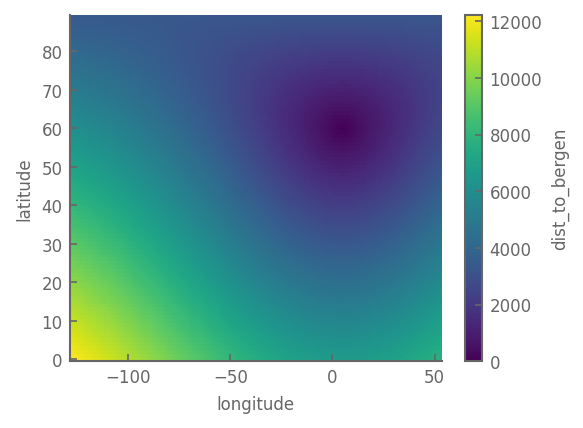

In [17]:
def haversine_np(lon1, lat1, lon2, lat2, radius=6371):
    # Convert degrees to radians
    lon1 = np.radians(lon1)
    lat1 = np.radians(lat1)
    lon2 = np.radians(lon2)
    lat2 = np.radians(lat2)
    # Compute differences
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    # Haversine formula
    a = np.sin(dlat / 2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return radius * c

grid = ds.isel(time_of_event=0, timestep_past=0, var_name=0, drop=True).features
grid_lons = grid-grid+grid.longitude
grid_lats = grid-grid+grid.latitude
bergen_lon = 5
bergen_lat = 60
dist_to_bergen = haversine_np(grid_lons, grid_lats, bergen_lon, bergen_lat).rename('dist_to_bergen')
dist_to_bergen.plot()

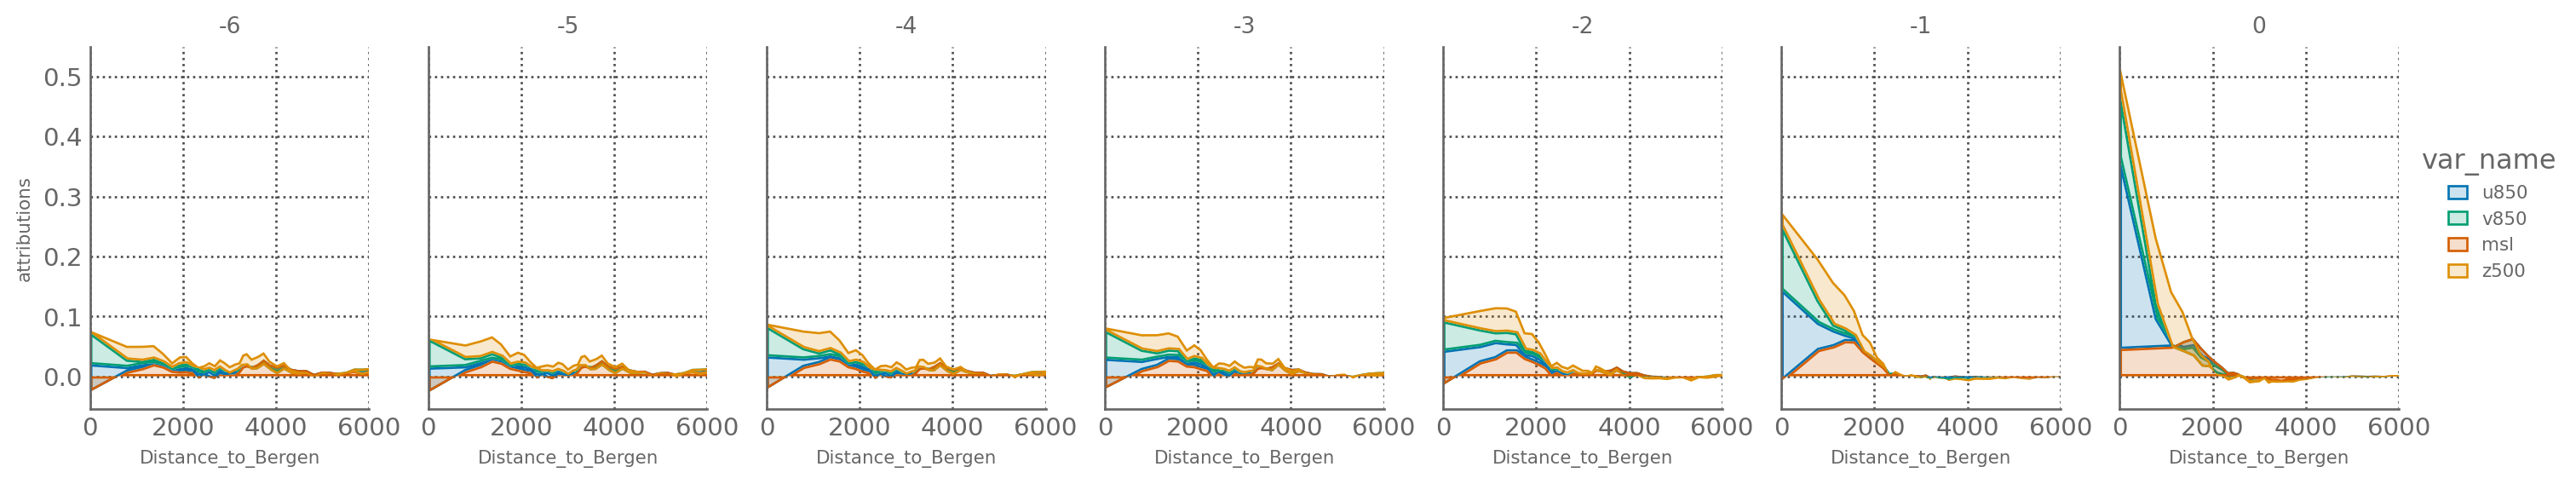

In [18]:
import flox.xarray

attributions_per_distance_to_bergen = flox.xarray.xarray_reduce(
    # variable qu'on veut aggréger 
    ds_TP.attributions,
    # Variables selon lesquelles on veut grouer : ici il y a deux variables mais on peut en rajouter autant qu'on veut
    dist_to_bergen,
    ds_TP.timestep_past,
    ds_TP.time_of_event,
    ds_TP.var_name,
    # Fonction à appliquer à chacun des groupes pour aggrégation
    func="mean",
    # Groupes attendus pour chacune des variables : soit on met les bins, soit on met None quand on veut grouper pour toutes les valeurs possibles
    expected_groups=(dist_to_bergen.quantile(np.arange(0,1.0001,.02)),
                    # np.arange(0,10001,500),
                    # np.arange(0,1.,.02), 
                     None,
                     None,
                     None,),
    # Déterminer si les groupes donnés correspondent à des bins ou non
    isbin=[True, False,False,False],
    # Méthode de calcul parallèl : flox propose plein de méthodes différentes pour optimiser les calculs en fonction de la forme des données
    method="map-reduce",
)
attributions_per_distance_to_bergen['dist_to_bergen_bins'] = [k.left for k in attributions_per_distance_to_bergen.dist_to_bergen_bins.values]
attributions_per_distance_to_bergen = attributions_per_distance_to_bergen.rename(dist_to_bergen_bins='Distance_to_Bergen')

mean_cumulative_attr = attributions_per_distance_to_bergen.sum(['Distance_to_Bergen','var_name'], min_count=1).mean('time_of_event')
df__ = ((attributions_per_distance_to_bergen).where(TP).mean('time_of_event')/mean_cumulative_attr).to_series().reset_index()
df__['var_type'] = ['wind' if '850' in k else 'pressure' for k in df__.var_name]

# sns.catplot(df__, x='dist_to_cyclone_bins', y='attributions', kind='bar', hue='var_name', multiple)#
(so.Plot(df__,x='Distance_to_Bergen', y='attributions', color='var_name' )
    .add(so.Area(), so.Stack())
    .facet(col='timestep_past', )
    .layout(size=(15,3))
    .theme(plt.style.library["robin"])
    .theme({'axes.grid':True, 'grid.color':'.3'})
    # .share(y=False)
    .limit(x=[0,6000])
    .scale(color=so.Nominal(['C0','C2','C3','C1'],order=['u850','v850','msl','z500',]))
    # .scale(x='log')
    )

# axs = f.axes

# , hue='var_name', multiple='stack')
# df__

## Distance to cyclone and bergen

In [19]:
import flox.xarray

attributions_per_distance_berg_cyc = flox.xarray.xarray_reduce(
    # variable qu'on veut aggréger 
    ds_TP.attributions,
    # Variables selon lesquelles on veut grouer : ici il y a deux variables mais on peut en rajouter autant qu'on veut
    ds_TP.distance_to_cyclone,
    dist_to_bergen,
    ds_TP.timestep_past,
    ds_TP.time_of_event,
    ds_TP.var_name,
    # Fonction à appliquer à chacun des groupes pour aggrégation
    func="sum",
    # Groupes attendus pour chacune des variables : soit on met les bins, soit on met None quand on veut grouper pour toutes les valeurs possibles
    expected_groups=(
                     ds_TP.distance_to_cyclone.quantile(np.arange(0,1.0001,.02)),
                     dist_to_bergen.quantile(np.arange(0,1.0001,.02)),
                    # np.arange(0,10001,100),
                    # np.arange(0,10001,100),
                    # np.arange(0,1.,.02), 
                     None,
                     None,
                     None,),
    # Déterminer si les groupes donnés correspondent à des bins ou non
    isbin=[True, True,False,False, False],
    # Méthode de calcul parallèl : flox propose plein de méthodes différentes pour optimiser les calculs en fonction de la forme des données
    method="map-reduce",
)
attributions_per_distance_berg_cyc['distance_to_cyclone_bins'] = [k.left for k in attributions_per_distance_berg_cyc.distance_to_cyclone_bins.values]
attributions_per_distance_berg_cyc['dist_to_bergen_bins'] = [k.left for k in attributions_per_distance_berg_cyc.dist_to_bergen_bins.values]

attributions_per_distance_berg_cyc = attributions_per_distance_berg_cyc.rename(distance_to_cyclone_bins='Distance_to_cyclone')
attributions_per_distance_berg_cyc = attributions_per_distance_berg_cyc.rename(dist_to_bergen_bins='Distance_to_Bergen')

In [20]:
ds_ = attributions_per_distance_berg_cyc.sum('var_name').assign_coords(Distance_to_cyclone = np.arange(0,1.0001,.02)[:-1], Distance_to_Bergen = np.arange(0,1.0001,.02)[:-1])
# ds_ = (ds_/ds_.sum(['Distance_to_cyclone','Distance_to_Bergen'])).mean('time_of_event')
# ds_.plot(col='timestep_past', vmax=.01)

In [22]:
ranks = ds_.stack(space=['Distance_to_Bergen','Distance_to_cyclone']).rank('space', pct=True).unstack()

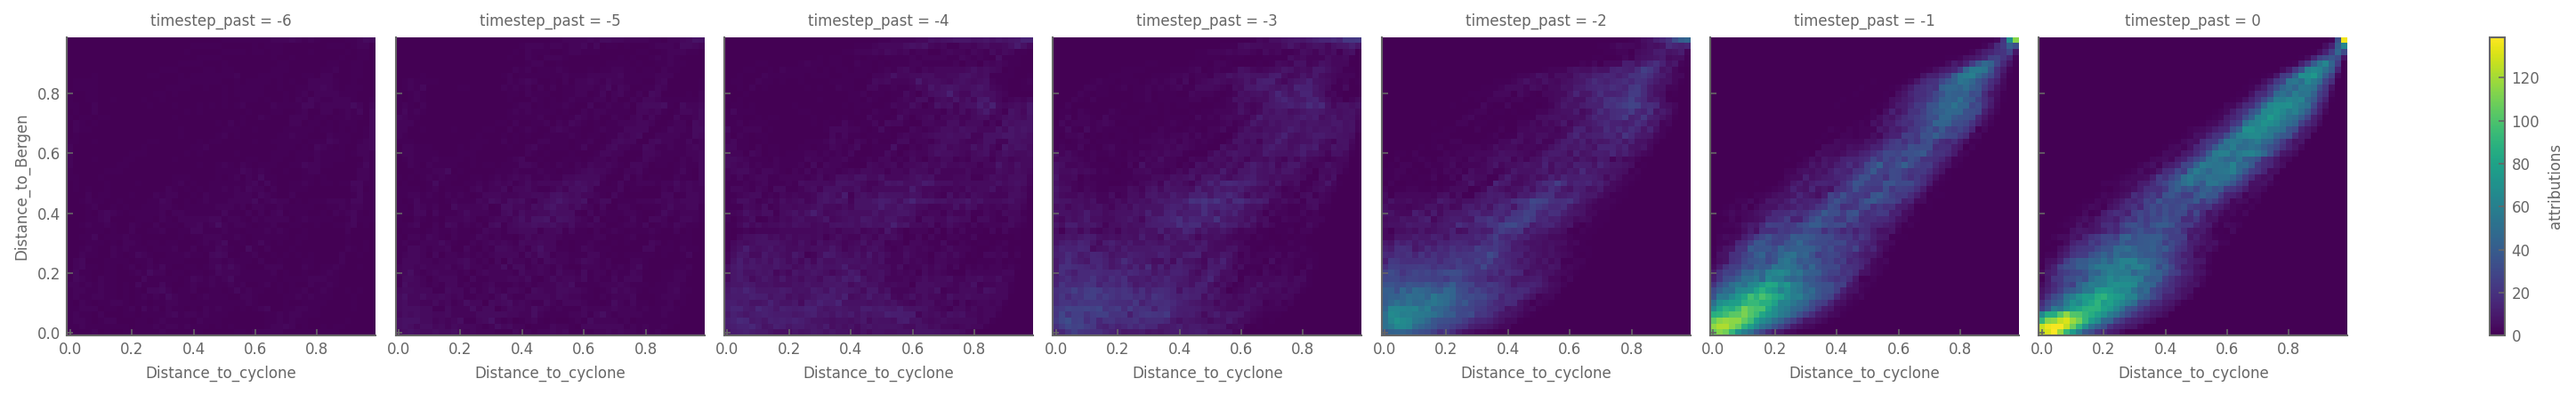

In [30]:
ranks.where(ranks>0.9).count('time_of_event').plot(col='timestep_past')

# OTHER STUFF

In [52]:
ds_features = xr.open_zarr( "/Data/gfi/users/rogui7909/data/ERA5/dynamical_variables/dl_inputs_day_1deg_1940-2024.zarr").data_normed.sel(var_name=ds.var_name)
ds_rain = xr.open_dataset('/Data/gfi/users/rogui7909/data/ERA5/precipitation/pr_era5_daily_westnorway_1940-2024.nc').tp.rolling(time=7).construct('timestep').shift(time=-7)
ds_rain = (ds_rain.where(ds_rain>20)/ds_rain).fillna(0)

In [57]:
X_train = ds_features.sel(time=slice(None,'1998')).values.reshape(21550,-1)
Y_train = ds_rain.sel(time=slice(None,'1998')).values.reshape(21550, -1)

from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import r2_score
pls = PLSRegression(n_components=10)

pls.fit(X_train, Y_train)

y_pred = pls.predict(X_train)

In [58]:
X_val = ds_features.sel(time=slice('1999','2010')).values.reshape(4383,-1)
Y_val = ds_rain.sel(time=slice('1999','2010')).values.reshape(4383, -1)
pred_val = pls.predict(X_val)

(array([[8.800e+01, 3.790e+02, 8.600e+02, 1.044e+03, 8.950e+02, 5.950e+02,
         3.130e+02, 1.270e+02, 6.500e+01, 1.700e+01],
        [8.000e+00, 2.250e+02, 8.630e+02, 1.283e+03, 1.098e+03, 5.800e+02,
         2.250e+02, 8.100e+01, 2.000e+01, 0.000e+00],
        [3.000e+00, 1.540e+02, 8.160e+02, 1.448e+03, 1.150e+03, 5.810e+02,
         1.800e+02, 4.400e+01, 7.000e+00, 0.000e+00],
        [2.000e+00, 1.160e+02, 7.830e+02, 1.520e+03, 1.193e+03, 5.890e+02,
         1.490e+02, 3.000e+01, 1.000e+00, 0.000e+00],
        [1.000e+00, 9.400e+01, 7.700e+02, 1.563e+03, 1.234e+03, 5.670e+02,
         1.330e+02, 2.000e+01, 1.000e+00, 0.000e+00],
        [0.000e+00, 6.400e+01, 7.390e+02, 1.605e+03, 1.296e+03, 5.520e+02,
         1.190e+02, 8.000e+00, 0.000e+00, 0.000e+00],
        [0.000e+00, 3.000e+01, 7.020e+02, 1.677e+03, 1.370e+03, 5.130e+02,
         8.700e+01, 4.000e+00, 0.000e+00, 0.000e+00]]),
 array([-0.16096731, -0.10424515, -0.04752299,  0.00919917,  0.06592133,
         0.12264349,  

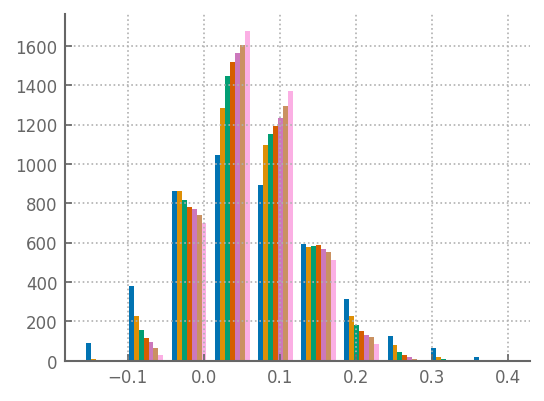

In [62]:
plt.hist(pred_val)

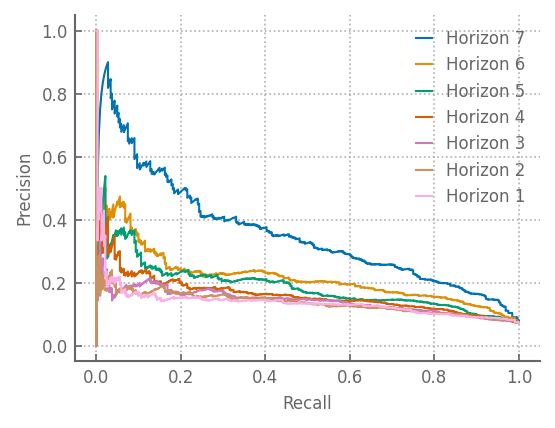

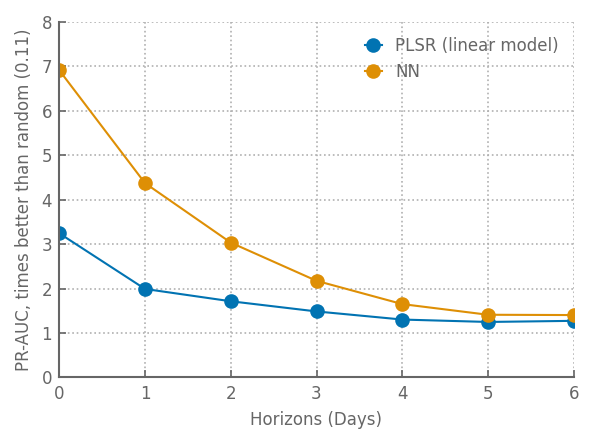

In [84]:
from sklearn.metrics import precision_recall_curve, average_precision_score

aps_plsr=[]
for k in range(7):
    targets = Y_val[:,k]
    predictions = pred_val[:,k]
    aps_plsr.append(average_precision_score(targets, predictions, pos_label=1)/.11)
    prec, recall, thresholds = precision_recall_curve(targets, predictions, pos_label=1)
    plt.plot(recall, prec, label=f'Horizon {7-k}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend()
plt.figure()
plt.plot(np.arange(0,7,1),aps_plsr, marker='o', label='PLSR (linear model)')
# plt.plot(np.arange(-6,1,1),aps_plsr, marker='o')
plt.plot(np.arange(6,-1,-1),aps, marker='o', label='NN')

plt.ylabel('PR-AUC, times better than random (0.11)')
plt.xlabel('Horizons (Days)')
plt.legend()
plt.xlim(0,6)
plt.ylim(0,8)

plt.tight_layout()


In [40]:
pred_val

array([[4.25144726, 5.03465616, 5.4248921 , ..., 6.00892742, 6.0965479 ,
        6.2128946 ],
       [6.9607435 , 7.18404567, 7.20214442, ..., 7.24333118, 7.12675721,
        7.04072973],
       [6.91790762, 6.52448087, 6.11734641, ..., 5.64031713, 5.60232511,
        5.63204722],
       ...,
       [5.21387915, 4.42936748, 3.92078944, ..., 3.74723158, 3.77580272,
        3.895368  ],
       [3.90332486, 3.8888948 , 3.91387009, ..., 4.15066242, 4.23479025,
        4.32768897],
       [6.43696022, 5.93369094, 5.86243737, ..., 6.01813908, 5.98314645,
        5.91822367]])

# Attributions stuff

In [113]:
attrs_TP = ds_TP.attributions.mean('time_of_event')
attrs_TP/attrs_TP.ma(['longitude','latitude'])
attrs_TP.plot(col='timestep_past', row='var_name',
             subplot_kws = dict(projection=ccrs.PlateCarree()),
              transform=ccrs.PlateCarree(),
             aspect=2)


NameError: name 'ds_TP' is not defined

In [12]:
import flox.xarray

attributions_per_distance = flox.xarray.xarray_reduce(
    # variable qu'on veut aggréger 
    ds_TP.attributions,
    # Variables selon lesquelles on veut grouer : ici il y a deux variables mais on peut en rajouter autant qu'on veut
    ds_TP.distance_to_cyclone,
    ds_TP.timestep_past,
    ds_TP.time_of_event,
    ds_TP.var_name,
    # Fonction à appliquer à chacun des groupes pour aggrégation
    func="mean",
    # Groupes attendus pour chacune des variables : soit on met les bins, soit on met None quand on veut grouper pour toutes les valeurs possibles
    expected_groups=(ds_TP.distance_to_cyclone.quantile(np.arange(0,1.0001,.02)),
                    # np.arange(0,10001,500),
                    # np.arange(0,1.,.02), 
                     None,
                     None,
                     None,),
    # Déterminer si les groupes donnés correspondent à des bins ou non
    isbin=[True, False,False,False],
    # Méthode de calcul parallèl : flox propose plein de méthodes différentes pour optimiser les calculs en fonction de la forme des données
    method="map-reduce",
)
attributions_per_distance['distance_to_cyclone_bins'] = [k.left for k in attributions_per_distance.distance_to_cyclone_bins.values]
attributions_per_distance = attributions_per_distance.rename(distance_to_cyclone_bins='Distance_to_cyclone')

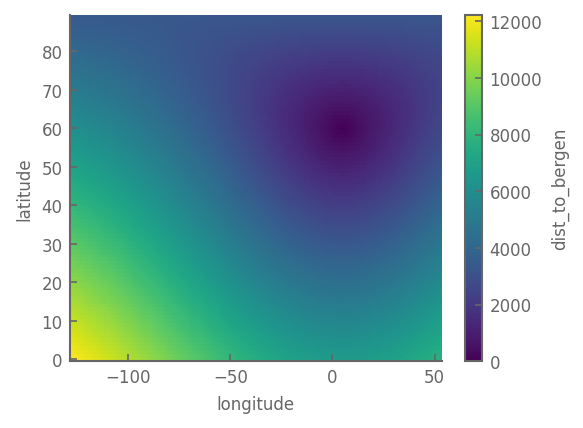

In [13]:
def haversine_np(lon1, lat1, lon2, lat2, radius=6371):
    # Convert degrees to radians
    lon1 = np.radians(lon1)
    lat1 = np.radians(lat1)
    lon2 = np.radians(lon2)
    lat2 = np.radians(lat2)
    # Compute differences
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    # Haversine formula
    a = np.sin(dlat / 2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return radius * c

grid = ds.isel(time_of_event=0, timestep_past=0, var_name=0, drop=True).features
grid_lons = grid-grid+grid.longitude
grid_lats = grid-grid+grid.latitude
bergen_lon = 5
bergen_lat = 60
dist_to_bergen = haversine_np(grid_lons, grid_lats, bergen_lon, bergen_lat).rename('dist_to_bergen')
dist_to_bergen.plot()

In [14]:
dist_to_bergen

<xarray.DataArray 'dist_to_bergen' (latitude: 90, longitude: 182)> Size: 131kB
array([[12224.52129251, 12180.97126872, 12136.83935604, ...,
         7747.6129388 ,  7790.56550351,  7834.1155273 ],
       [12122.03176016, 12078.73244158, 12034.84857901, ...,
         7644.97607837,  7688.18251447,  7731.98383938],
       [12019.44214626, 11976.39302166, 11932.75687424, ...,
         7542.45161436,  7585.91278767,  7629.96609245],
       ...,
       [ 3570.9141502 ,  3566.87667089,  3562.77105418, ...,
         3112.5247284 ,  3117.01873972,  3121.58040208],
       [ 3490.95391005,  3488.20683499,  3485.41425597, ...,
         3185.00965619,  3187.94451881,  3190.92500925],
       [ 3412.56128178,  3411.1593952 ,  3409.73477028, ...,
         3259.49564561,  3260.9329578 ,  3262.39326418]])
Coordinates:
  * longitude  (longitude) float64 1kB -128.0 -127.0 -126.0 ... 51.0 52.0 53.0
  * latitude   (latitude) float64 720B 0.0 1.0 2.0 3.0 ... 86.0 87.0 88.0 89.0

In [65]:
import flox.xarray

attributions_per_distance_berg_cyc = flox.xarray.xarray_reduce(
    # variable qu'on veut aggréger 
    ds_TP.attributions,
    # Variables selon lesquelles on veut grouer : ici il y a deux variables mais on peut en rajouter autant qu'on veut
    ds_TP.distance_to_cyclone,
    dist_to_bergen,
    ds_TP.timestep_past,
    ds_TP.time_of_event,
    ds_TP.var_name,
    # Fonction à appliquer à chacun des groupes pour aggrégation
    func="sum",
    # Groupes attendus pour chacune des variables : soit on met les bins, soit on met None quand on veut grouper pour toutes les valeurs possibles
    expected_groups=(
                     # ds_TP.distance_to_cyclone.quantile(np.arange(0,1.0001,.02)),
                     # dist_to_bergen.quantile(np.arange(0,1.0001,.02)),
                    np.arange(0,10001,500),
                    np.arange(0,10001,500),
                    # np.arange(0,1.,.02), 
                     None,
                     None,
                     None,),
    # Déterminer si les groupes donnés correspondent à des bins ou non
    isbin=[True, True,False,False, False],
    # Méthode de calcul parallèl : flox propose plein de méthodes différentes pour optimiser les calculs en fonction de la forme des données
    method="map-reduce",
)
attributions_per_distance_berg_cyc['distance_to_cyclone_bins'] = [k.left for k in attributions_per_distance_berg_cyc.distance_to_cyclone_bins.values]
attributions_per_distance_berg_cyc['dist_to_bergen_bins'] = [k.left for k in attributions_per_distance_berg_cyc.dist_to_bergen_bins.values]

attributions_per_distance_berg_cyc = attributions_per_distance_berg_cyc.rename(distance_to_cyclone_bins='Distance_to_cyclone')
attributions_per_distance_berg_cyc = attributions_per_distance_berg_cyc.rename(dist_to_bergen_bins='Distance_to_Bergen')

In [70]:
is_cyclone = ds_TP.distance_to_cyclone.isel(longitude=50, latitude=50, drop=True).notnull().sum('timestep_past') == 7
full_TP = ((ds_TP.predictions>threshs).sum('timestep_past') == 7)
times = is_cyclone.where(is_cyclone*full_TP, drop=True).time_of_event
# ds_TP.where(is_cyclone & full_TP)
times

<xarray.DataArray 'time_of_event' (time_of_event: 4)> Size: 32B
array(['2001-10-29T00:00:00.000000000', '2006-12-09T00:00:00.000000000',
       '2008-01-22T00:00:00.000000000', '2011-12-19T00:00:00.000000000'],
      dtype='datetime64[ns]')
Coordinates:
  * time_of_event  (time_of_event) datetime64[ns] 32B 2001-10-29 ... 2011-12-19

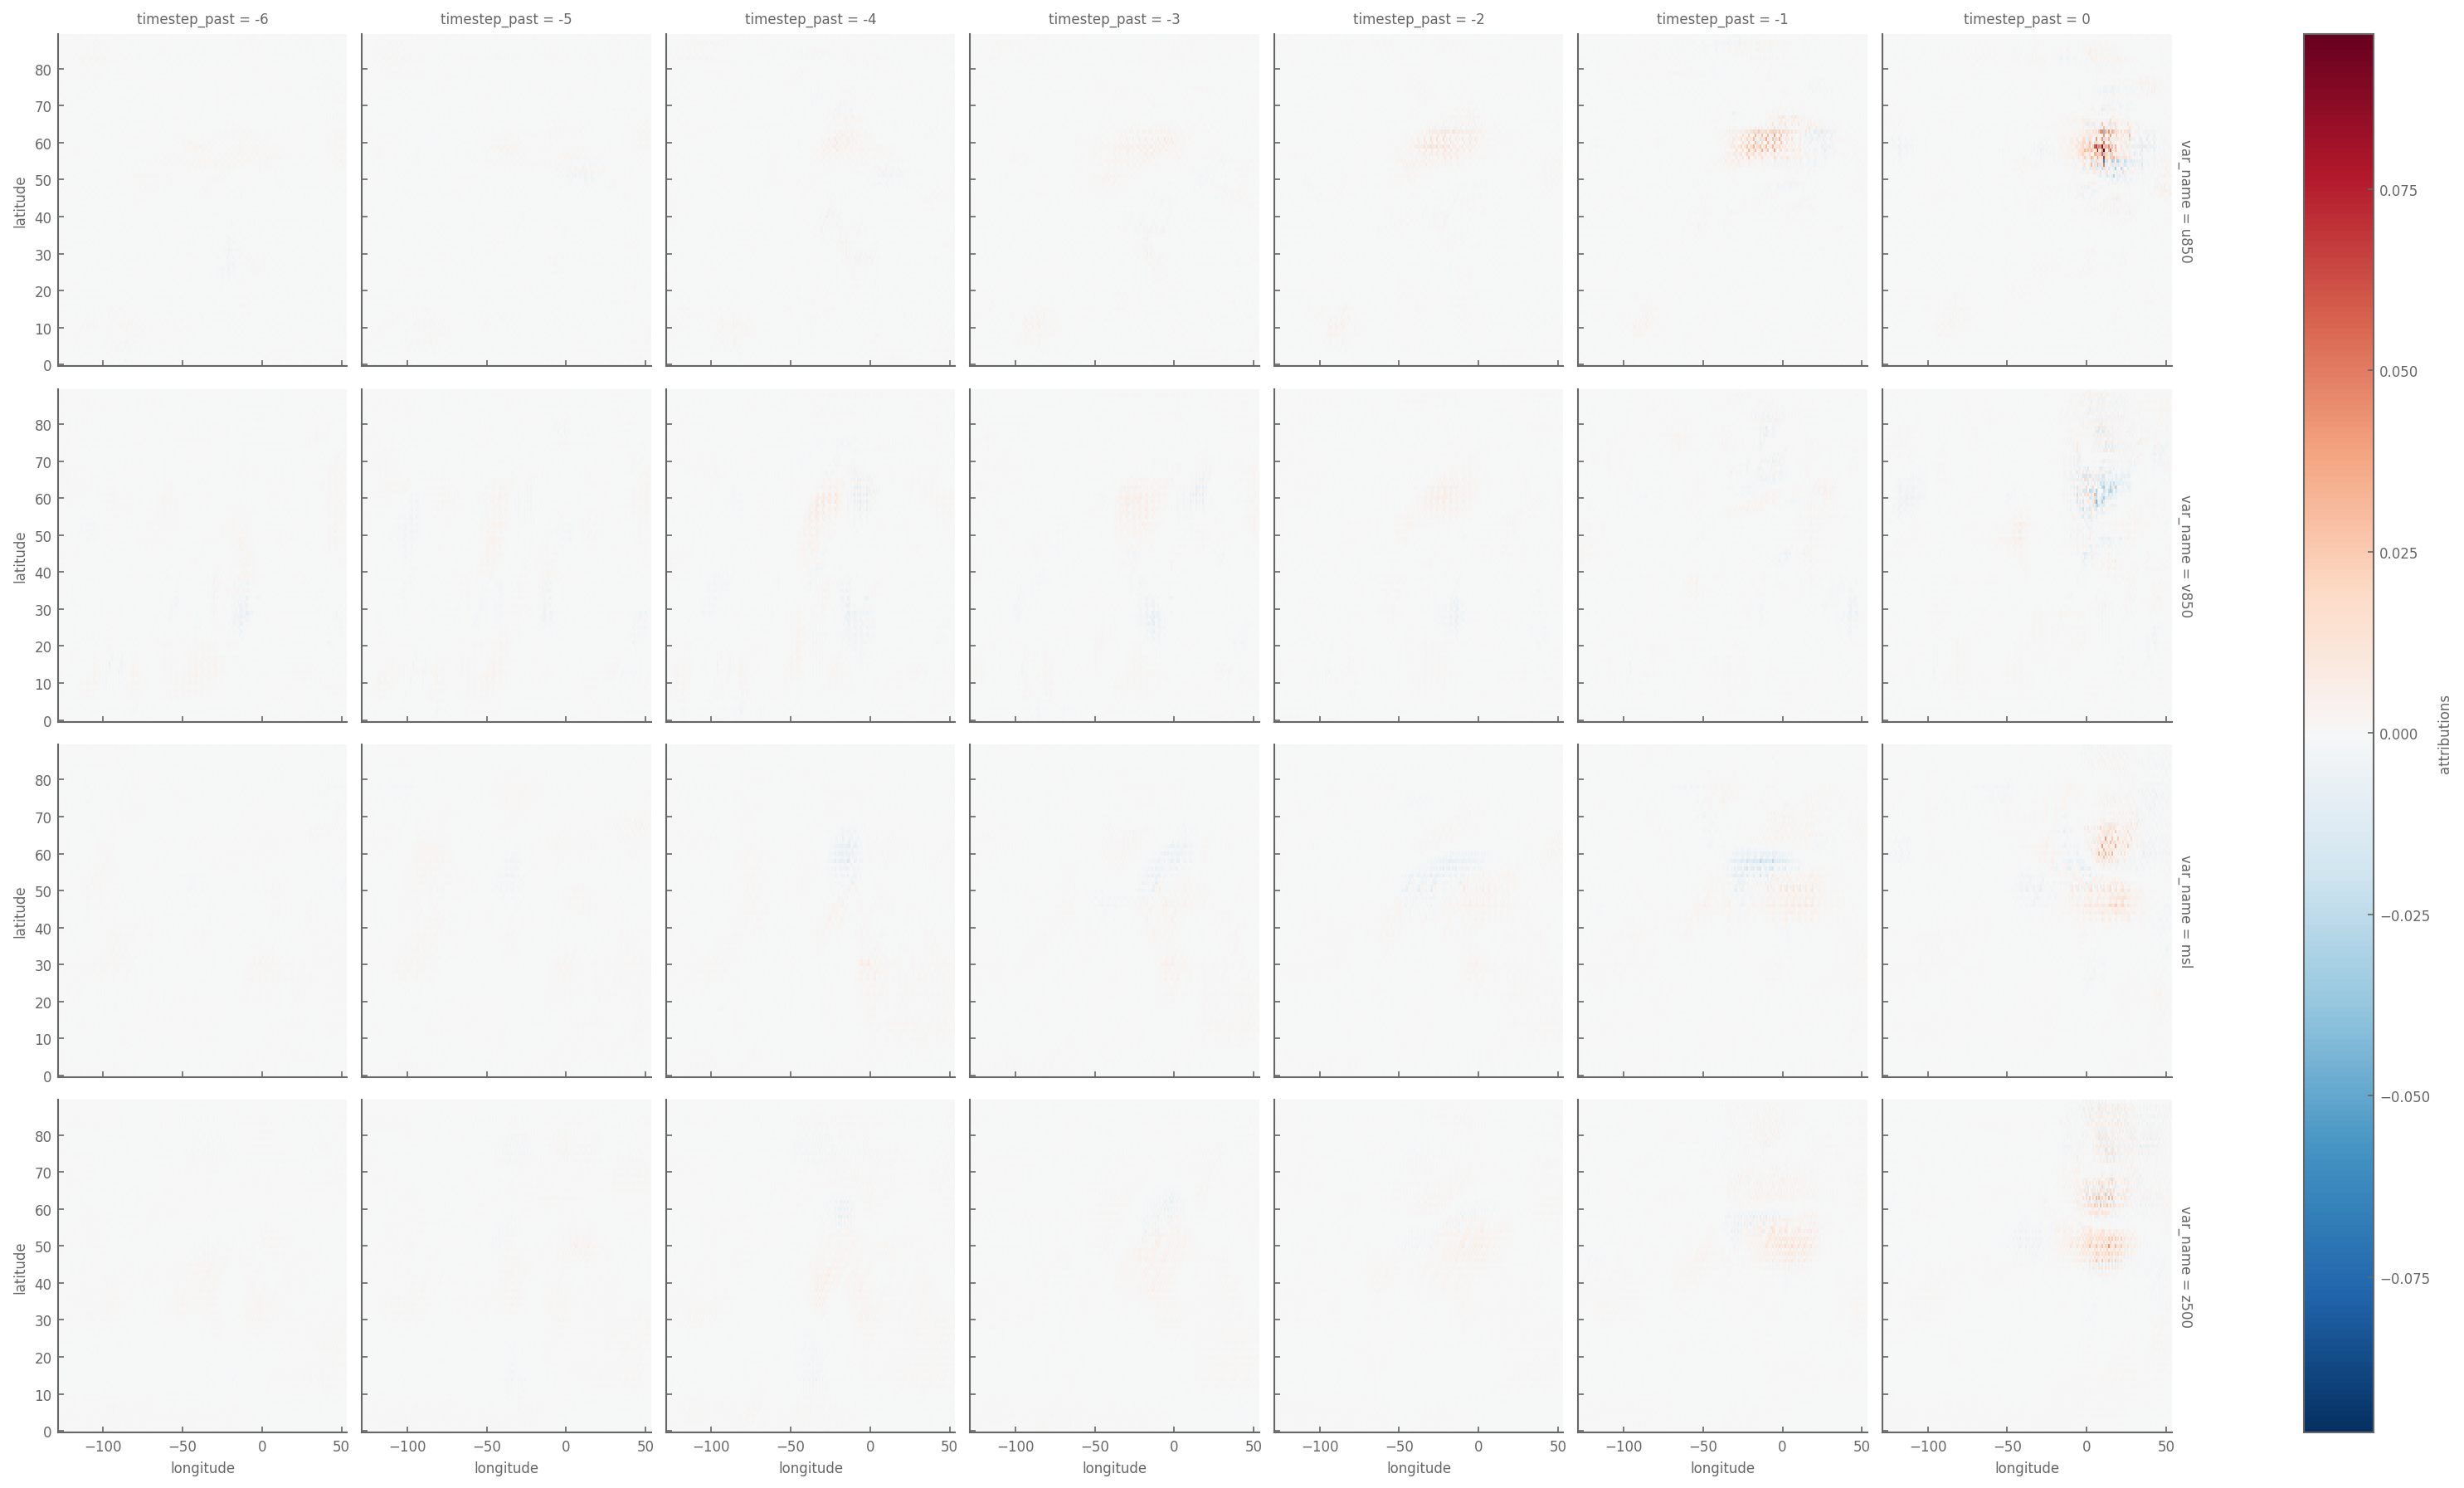

In [108]:
ds.sel(time_of_event=times[0]).attributions.plot(col='timestep_past', row='var_name')

In [ ]:
ds_ = ds_TP
ds_['dist_to_bergen'] = dist_to_bergen
df_ = ds_[['attributions','distance_to_cyclone','dist_to_bergen']].to_dataframe().reset_index()
ds_ = df_.groupby([pd.cut(df_.distance_to_cyclone, np.arange(0,10001,500)),
            pd.cut(df_.dist_to_bergen, np.arange(0,10001,500)),
                  'timestep_past']
           ).attributions.sum().to_xarray()

# plt.grid()
(ds_/ds_.max(['dist_to_bergen','distance_to_cyclone'])).plot(col='timestep_past')

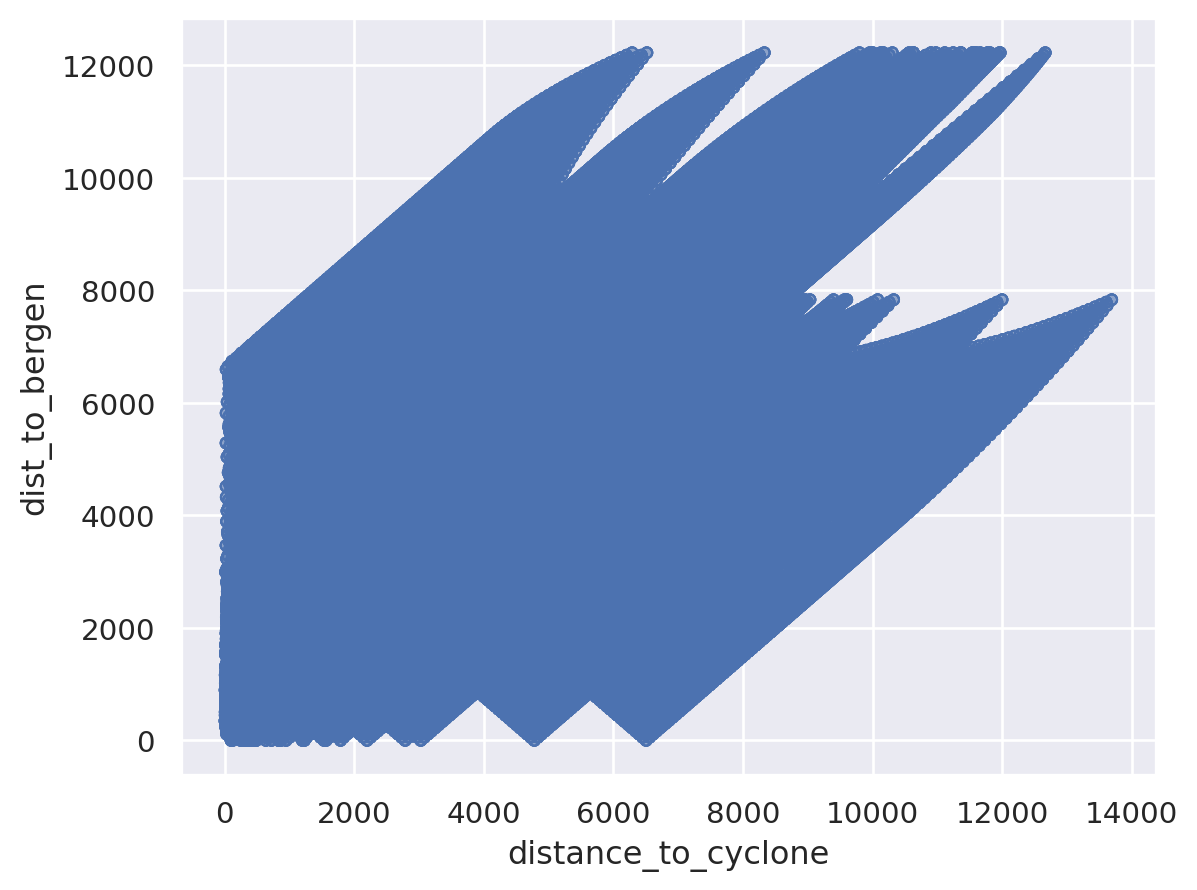

In [80]:
ds_ = ds.sel(time_of_event=times)
ds_['dist_to_bergen'] = dist_to_bergen
df_ = ds_[['attributions','distance_to_cyclone','dist_to_bergen']].to_dataframe().reset_index()
df_
(so.Plot(df_, x='distance_to_cyclone',y='dist_to_bergen')
    .add(so.Dots())
)

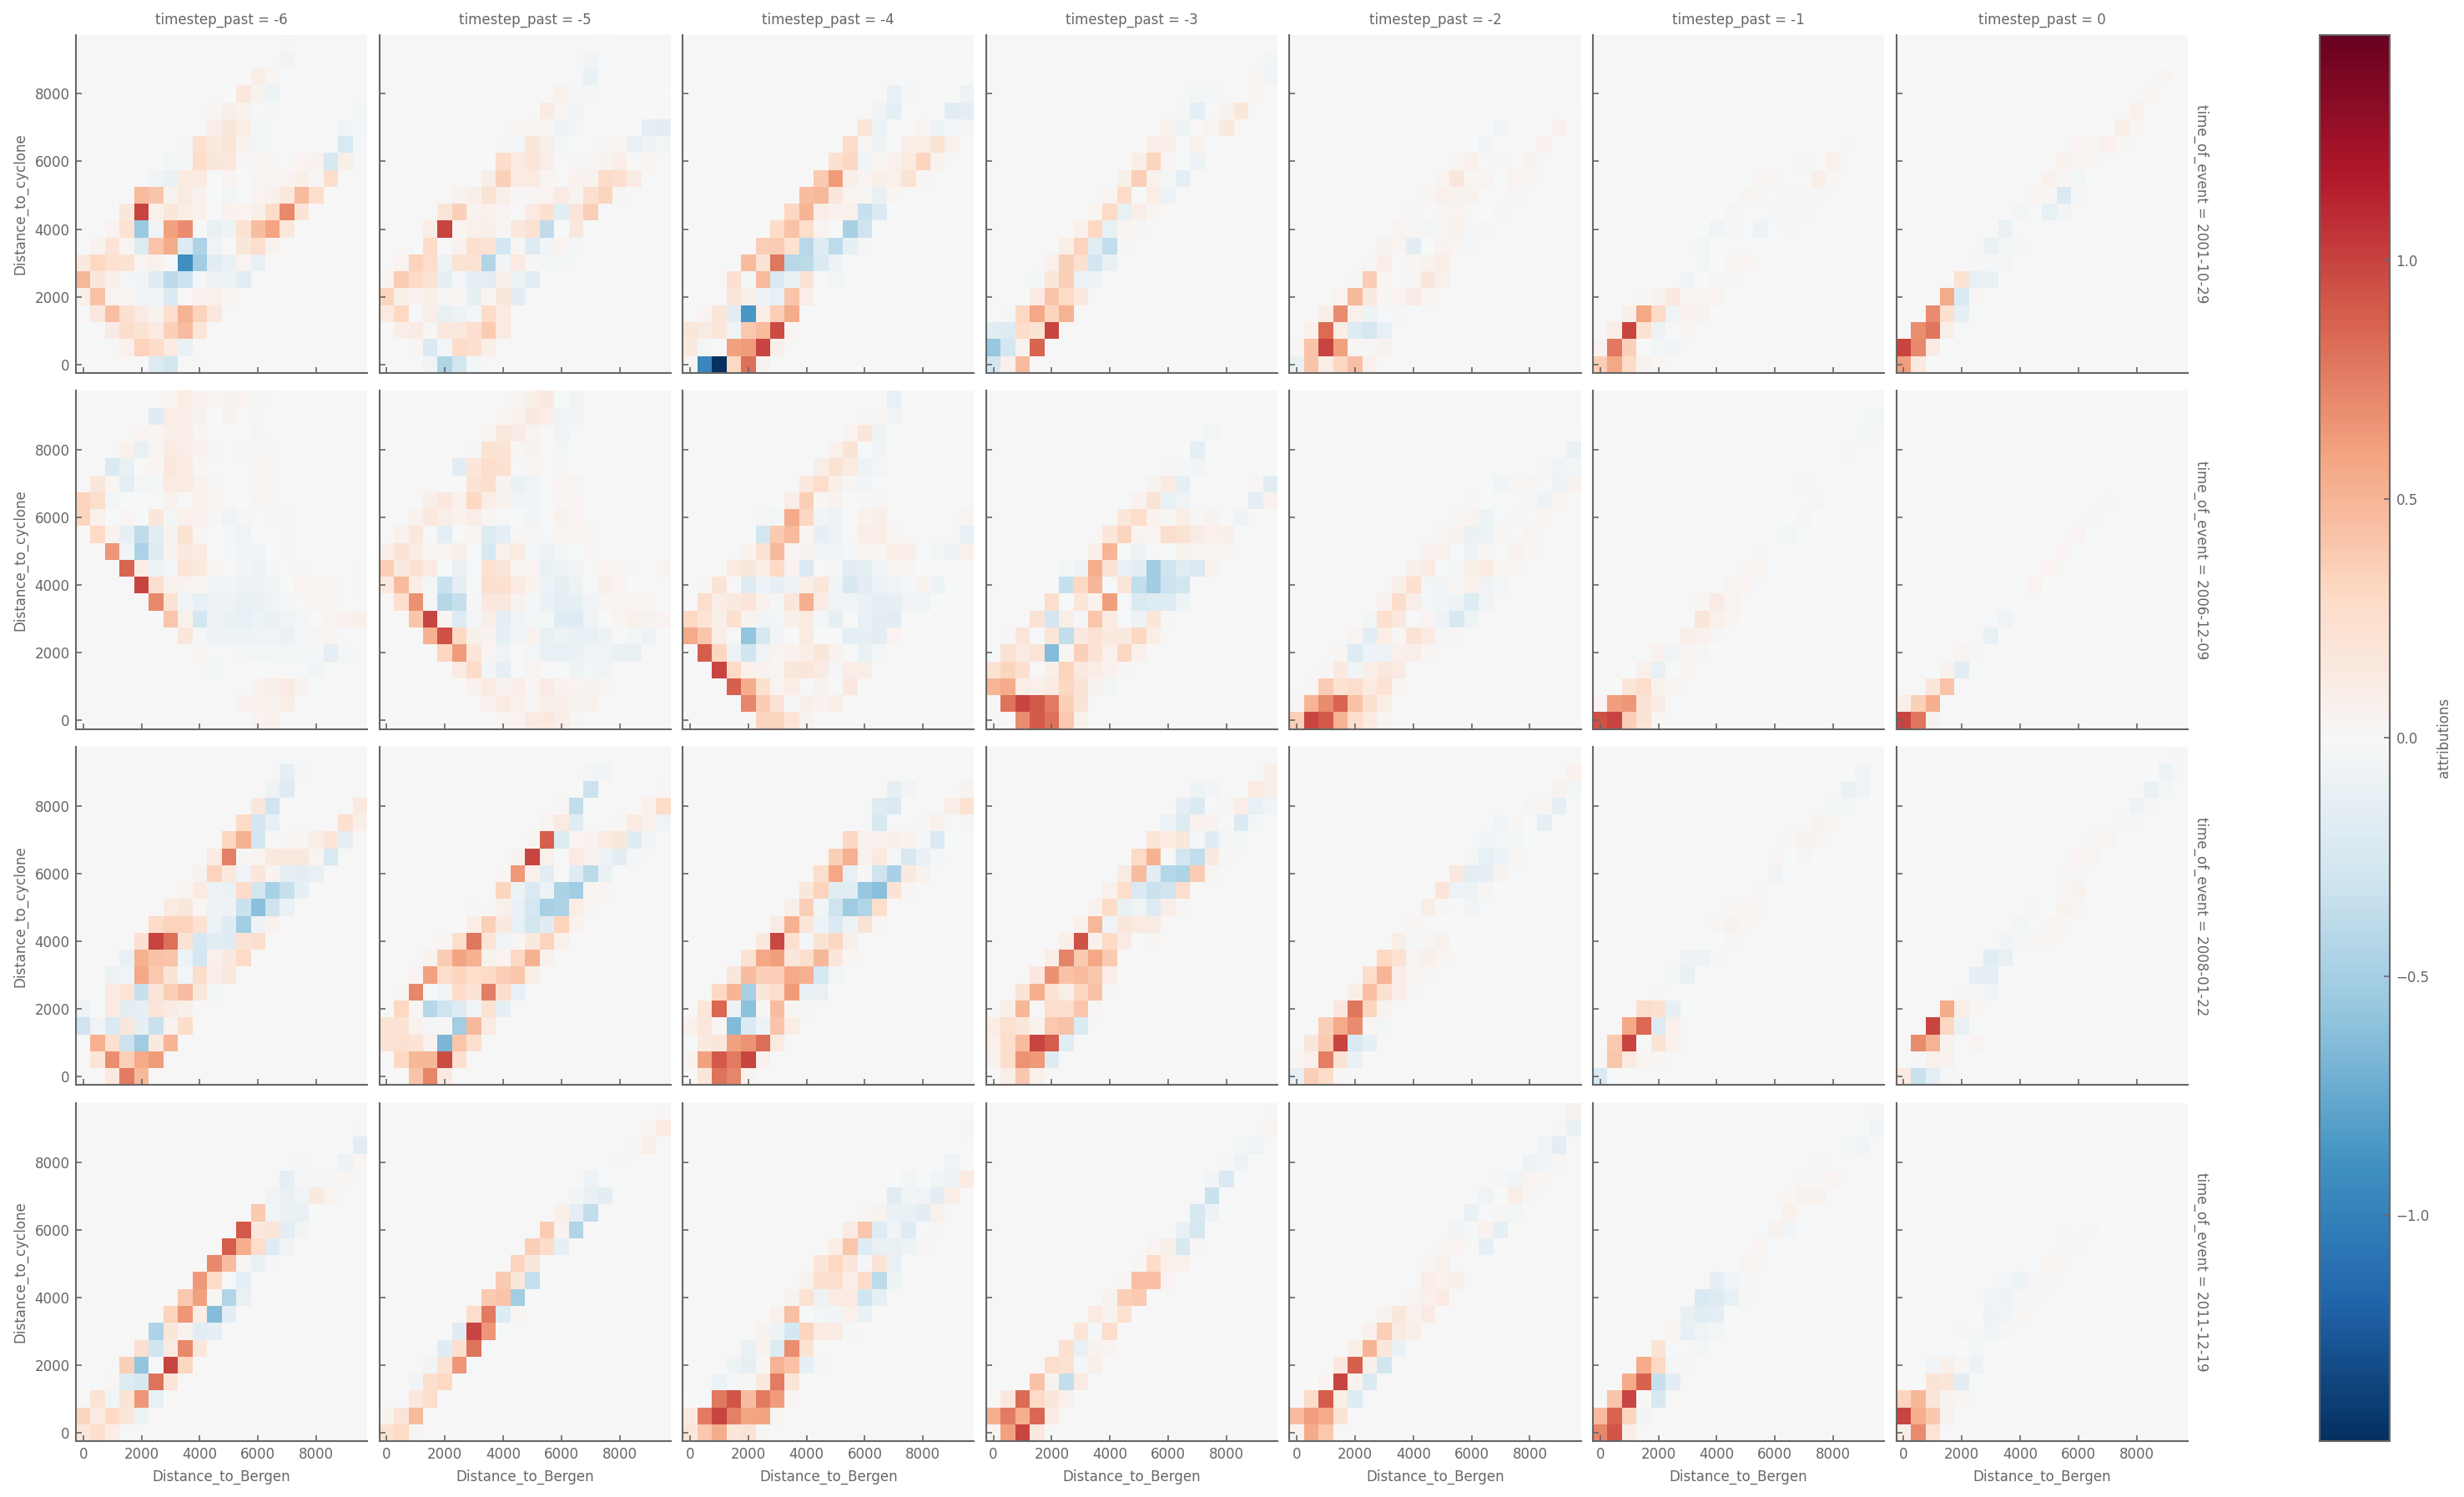

In [67]:
ds_ = attributions_per_distance_berg_cyc.sum('var_name').sel(time_of_event=times)
(ds_/ds_.max(['Distance_to_cyclone','Distance_to_Bergen'])).plot(col='timestep_past', row='time_of_event')


In [ ]:
ds.distance_to_cyclone.isel(longitude=50, latitude=50).notnull().sum('timestep_past')==7

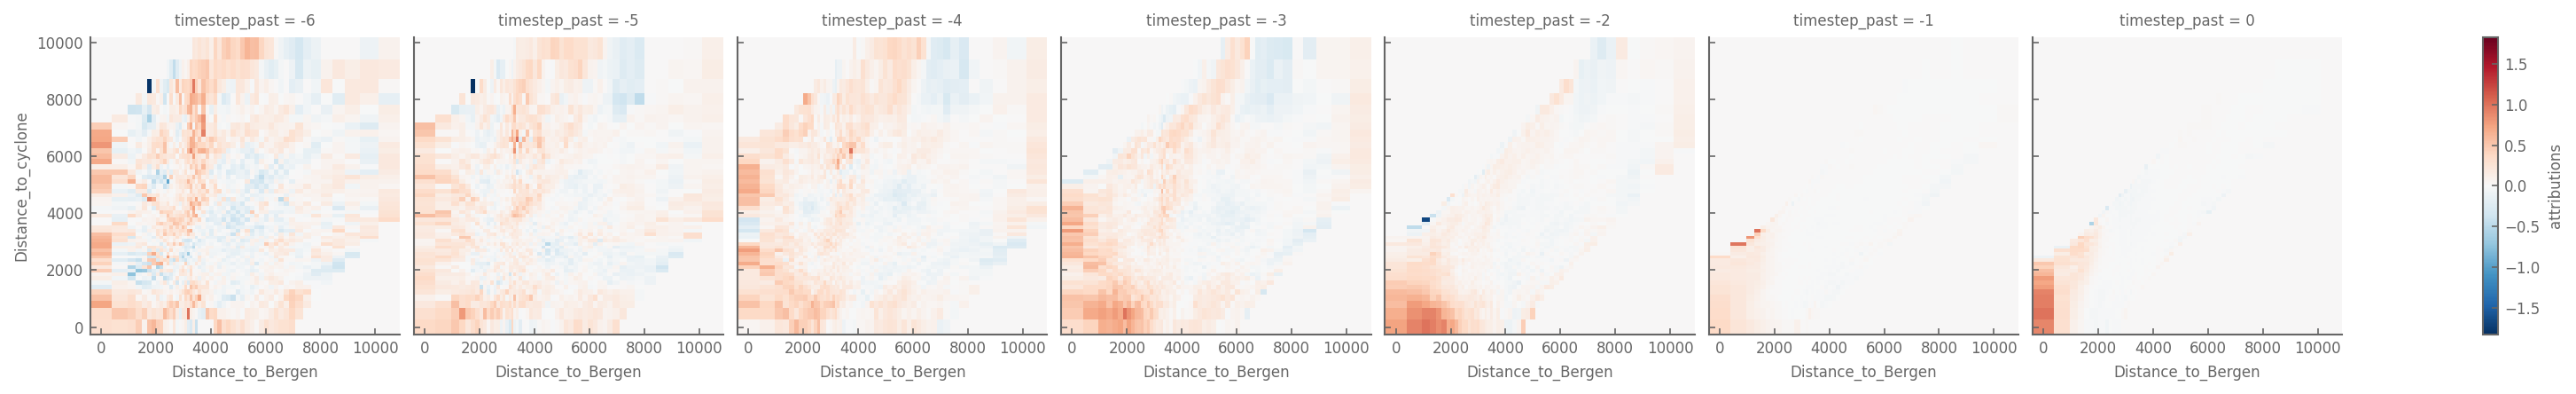

In [86]:
ds_ = attributions_per_distance_berg_cyc.where(ds.predictions>threshs).mean('time_of_event').sum('var_name')
    
(ds_/ds_.max(['Distance_to_cyclone','Distance_to_Bergen'])).plot(col='timestep_past')

In [61]:
import flox.xarray

attributions_per_distance_to_bergen = flox.xarray.xarray_reduce(
    # variable qu'on veut aggréger 
    ds_TP.attributions,
    # Variables selon lesquelles on veut grouer : ici il y a deux variables mais on peut en rajouter autant qu'on veut
    dist_to_bergen,
    ds_TP.timestep_past,
    ds_TP.time_of_event,
    ds_TP.var_name,
    # Fonction à appliquer à chacun des groupes pour aggrégation
    func="mean",
    # Groupes attendus pour chacune des variables : soit on met les bins, soit on met None quand on veut grouper pour toutes les valeurs possibles
    expected_groups=(dist_to_bergen.quantile(np.arange(0,1.0001,.02)),
                    # np.arange(0,10001,500),
                    # np.arange(0,1.,.02), 
                     None,
                     None,
                     None,),
    # Déterminer si les groupes donnés correspondent à des bins ou non
    isbin=[True, False,False,False],
    # Méthode de calcul parallèl : flox propose plein de méthodes différentes pour optimiser les calculs en fonction de la forme des données
    method="map-reduce",
)
attributions_per_distance_to_bergen['dist_to_bergen_bins'] = [k.left for k in attributions_per_distance_to_bergen.dist_to_bergen_bins.values]
attributions_per_distance_to_bergen = attributions_per_distance_to_bergen.rename(dist_to_bergen_bins='Distance_to_Bergen')

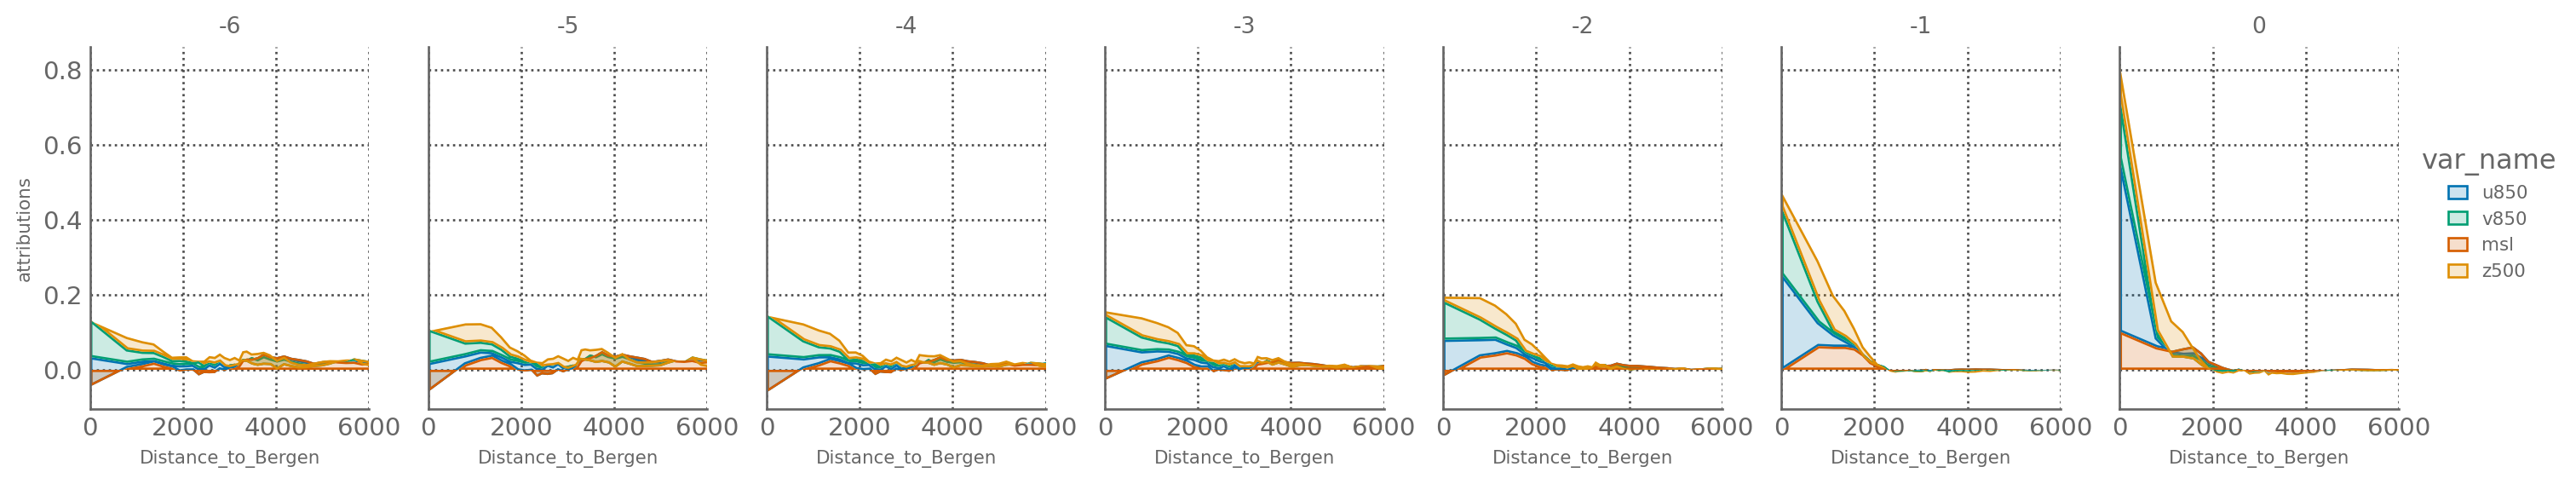

In [65]:
import flox.xarray

attributions_per_distance_to_bergen = flox.xarray.xarray_reduce(
    # variable qu'on veut aggréger 
    ds_TP.attributions,
    # Variables selon lesquelles on veut grouer : ici il y a deux variables mais on peut en rajouter autant qu'on veut
    dist_to_bergen,
    ds_TP.timestep_past,
    ds_TP.time_of_event,
    ds_TP.var_name,
    # Fonction à appliquer à chacun des groupes pour aggrégation
    func="mean",
    # Groupes attendus pour chacune des variables : soit on met les bins, soit on met None quand on veut grouper pour toutes les valeurs possibles
    expected_groups=(dist_to_bergen.quantile(np.arange(0,1.0001,.02)),
                    # np.arange(0,10001,500),
                    # np.arange(0,1.,.02), 
                     None,
                     None,
                     None,),
    # Déterminer si les groupes donnés correspondent à des bins ou non
    isbin=[True, False,False,False],
    # Méthode de calcul parallèl : flox propose plein de méthodes différentes pour optimiser les calculs en fonction de la forme des données
    method="map-reduce",
)
attributions_per_distance_to_bergen['dist_to_bergen_bins'] = [k.left for k in attributions_per_distance_to_bergen.dist_to_bergen_bins.values]
attributions_per_distance_to_bergen = attributions_per_distance_to_bergen.rename(dist_to_bergen_bins='Distance_to_Bergen')

mean_cumulative_attr = attributions_per_distance_to_bergen.sum(['Distance_to_Bergen','var_name'], min_count=1).mean('time_of_event')
df__ = ((attributions_per_distance_to_bergen).where(TP).mean('time_of_event')/mean_cumulative_attr).to_series().reset_index()
df__['var_type'] = ['wind' if '850' in k else 'pressure' for k in df__.var_name]

# sns.catplot(df__, x='dist_to_cyclone_bins', y='attributions', kind='bar', hue='var_name', multiple)#
(so.Plot(df__,x='Distance_to_Bergen', y='attributions', color='var_name' )
    .add(so.Area(), so.Stack())
    .facet(col='timestep_past', )
    .layout(size=(15,3))
    .theme(plt.style.library["robin"])
    .theme({'axes.grid':True, 'grid.color':'.3'})
    # .share(y=False)
    .limit(x=[0,6000])
    .scale(color=so.Nominal(['C0','C2','C3','C1'],order=['u850','v850','msl','z500',]))
    # .scale(x='log')
    )

# axs = f.axes

# , hue='var_name', multiple='stack')
# df__

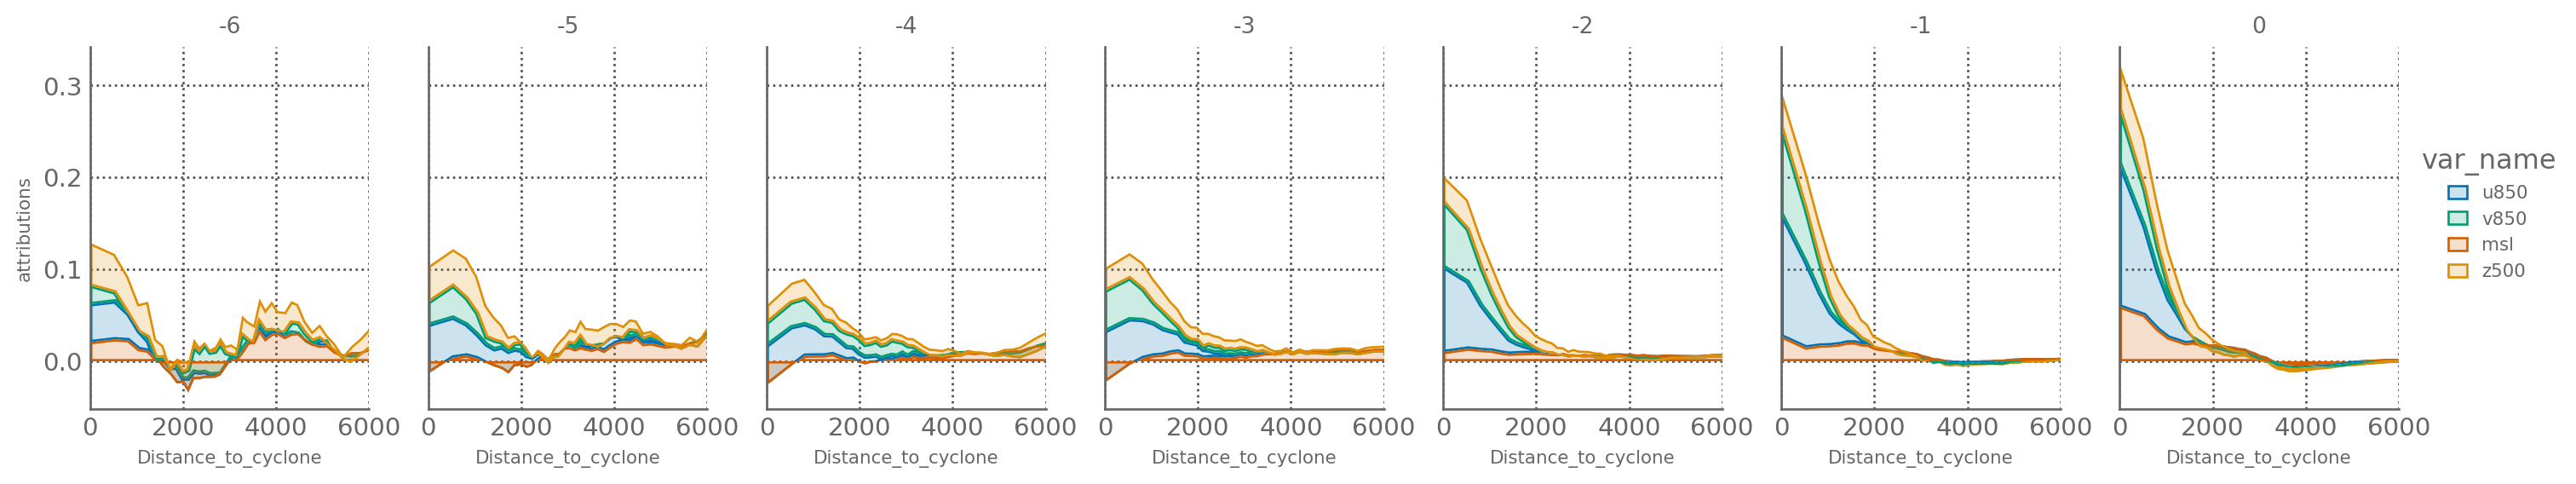

In [62]:
mean_cumulative_attr = attributions_per_distance.sum(['Distance_to_cyclone','var_name'], min_count=1).mean('time_of_event')
df__ = ((attributions_per_distance).where(TP).mean('time_of_event')/mean_cumulative_attr).to_series().reset_index()
df__['var_type'] = ['wind' if '850' in k else 'pressure' for k in df__.var_name]

# sns.catplot(df__, x='dist_to_cyclone_bins', y='attributions', kind='bar', hue='var_name', multiple)#
(so.Plot(df__,x='Distance_to_cyclone', y='attributions', color='var_name' )
    .add(so.Area(), so.Stack())
    .facet(col='timestep_past', )
    .layout(size=(15,3))
    .theme(plt.style.library["robin"])
    .theme({'axes.grid':True, 'grid.color':'.3'})
    # .share(y=False)
    .limit(x=[0,6000])
    .scale(color=so.Nominal(['C0','C2','C3','C1'],order=['u850','v850','msl','z500',]))
    # .scale(x='log')
    )

# axs = f.axes

# , hue='var_name', multiple='stack')
# df__